In [6]:
import numpy as np
import scipy
import jax
from jax import numpy as jnp
from jax import random as jr
from jax.scipy.special import logsumexp as LSE
from matplotlib import pyplot as plt
import pickle as pkl
import math
# from scipy.special import logsumexp as LSE
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=16)

import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.95'

from tqdm import tqdm

from matplotlib import pyplot as plt
from matplotlib import patches
from matplotlib import text as mtext

class CurvedText(mtext.Text):
    """
    A text object that follows an arbitrary curve.
    """
    def __init__(self, x, y, text, axes, latex=False, **kwargs):
        super(CurvedText, self).__init__(x[0],y[0],' ', **kwargs)

        axes.add_artist(self)

        ##saving the curve:
        self.__x = x
        self.__y = y
        self.__zorder = self.get_zorder()

        ##creating the text objects
        self.__Characters = []
        if latex:
            c = text
            if c == ' ':
                ##make this an invisible 'a':
                t = mtext.Text(0,0,'a')
                t.set_alpha(0.0)
            else:
                t = mtext.Text(0,0,c, **kwargs)

            #resetting unnecessary arguments
            t.set_ha('center')
            t.set_rotation(0)
            t.set_zorder(self.__zorder +1)

            self.__Characters.append((c,t))
            axes.add_artist(t)
        else:
            for c in text:
                if c == ' ':
                    ##make this an invisible 'a':
                    t = mtext.Text(0,0,'a')
                    t.set_alpha(0.0)
                else:
                    t = mtext.Text(0,0,c, **kwargs)

                #resetting unnecessary arguments
                t.set_ha('center')
                t.set_rotation(0)
                t.set_zorder(self.__zorder +1)

                self.__Characters.append((c,t))
                axes.add_artist(t)


    ##overloading some member functions, to assure correct functionality
    ##on update
    def set_zorder(self, zorder):
        super(CurvedText, self).set_zorder(zorder)
        self.__zorder = self.get_zorder()
        for c,t in self.__Characters:
            t.set_zorder(self.__zorder+1)

    def draw(self, renderer, *args, **kwargs):
        """
        Overload of the Text.draw() function. Do not do
        do any drawing, but update the positions and rotation
        angles of self.__Characters.
        """
        self.update_positions(renderer)

    def update_positions(self,renderer):
        """
        Update positions and rotations of the individual text elements.
        """

        #preparations

        ##determining the aspect ratio:
        ##from https://stackoverflow.com/a/42014041/2454357

        ##data limits
        xlim = self.axes.get_xlim()
        ylim = self.axes.get_ylim()
        ## Axis size on figure
        figW, figH = self.axes.get_figure().get_size_inches()
        ## Ratio of display units
        _, _, w, h = self.axes.get_position().bounds
        ##final aspect ratio
        aspect = ((figW * w)/(figH * h))*(ylim[1]-ylim[0])/(xlim[1]-xlim[0])

        #points of the curve in figure coordinates:
        x_fig,y_fig = (
            np.array(l) for l in zip(*self.axes.transData.transform([
            (i,j) for i,j in zip(self.__x,self.__y)
            ]))
        )

        #point distances in figure coordinates
        x_fig_dist = (x_fig[1:]-x_fig[:-1])
        y_fig_dist = (y_fig[1:]-y_fig[:-1])
        r_fig_dist = np.sqrt(x_fig_dist**2+y_fig_dist**2)

        #arc length in figure coordinates
        l_fig = np.insert(np.cumsum(r_fig_dist),0,0)

        #angles in figure coordinates
        rads = np.arctan2((y_fig[1:] - y_fig[:-1]),(x_fig[1:] - x_fig[:-1]))
        degs = np.rad2deg(rads)


        rel_pos = 10
        for c,t in self.__Characters:
            #finding the width of c:
            t.set_rotation(0)
            t.set_va('center')
            bbox1  = t.get_window_extent(renderer=renderer)
            w = bbox1.width
            h = bbox1.height

            #ignore all letters that don't fit:
            if rel_pos+w/2 > l_fig[-1]:
                t.set_alpha(0.0)
                rel_pos += w
                continue

            elif c != ' ':
                t.set_alpha(1.0)

            #finding the two data points between which the horizontal
            #center point of the character will be situated
            #left and right indices:
            il = np.where(rel_pos+w/2 >= l_fig)[0][-1]
            ir = np.where(rel_pos+w/2 <= l_fig)[0][0]

            #if we exactly hit a data point:
            if ir == il:
                ir += 1

            #how much of the letter width was needed to find il:
            used = l_fig[il]-rel_pos
            rel_pos = l_fig[il]

            #relative distance between il and ir where the center
            #of the character will be
            fraction = (w/2-used)/r_fig_dist[il]

            ##setting the character position in data coordinates:
            ##interpolate between the two points:
            x = self.__x[il]+fraction*(self.__x[ir]-self.__x[il])
            y = self.__y[il]+fraction*(self.__y[ir]-self.__y[il])

            #getting the offset when setting correct vertical alignment
            #in data coordinates
            t.set_va(self.get_va())
            bbox2  = t.get_window_extent(renderer=renderer)

            bbox1d = self.axes.transData.inverted().transform(bbox1)
            bbox2d = self.axes.transData.inverted().transform(bbox2)
            dr = np.array(bbox2d[0]-bbox1d[0])

            #the rotation/stretch matrix
            rad = rads[il]
            rot_mat = np.array([
                [math.cos(rad), math.sin(rad)*aspect],
                [-math.sin(rad)/aspect, math.cos(rad)]
            ])

            ##computing the offset vector of the rotated character
            drp = np.dot(dr,rot_mat)

            #setting final position and rotation:
            t.set_position(np.array([x,y])+drp)
            t.set_rotation(degs[il])

            t.set_va('center')
            t.set_ha('center')

            #updating rel_pos to right edge of character
            rel_pos += w-used

colors = ["#000000","#b00069",'#00B862',"#0d2ec1",'#F7005A']

Number succeed: 0, NPE: 10:   0%|          | 0/51 [00:09<?, ?it/s]


KeyboardInterrupt: 

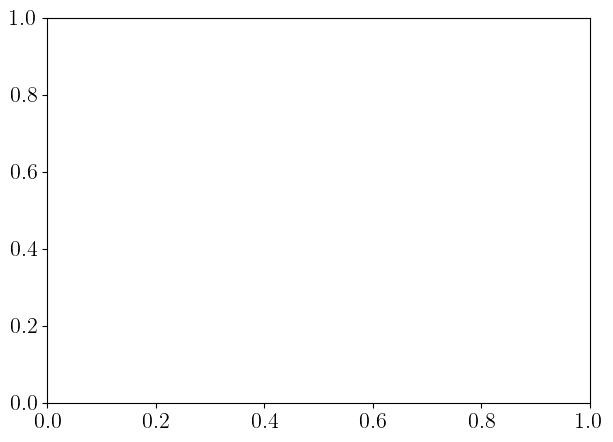

In [7]:
# I WANT THE MEAN OF THE <KL(<Phat> || Phat)> 
# ABOVE WAS ASSESSING BIAS!, THIS ASSESSES RANDOM SCATTER

import jax
from jax.scipy.special import logsumexp as LSE
import jax.numpy as jnp
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '4'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.95'

nsample = 10000
larger_nsample = 100000
npes = np.array(
    [10,  11,  12,  13,  14,  15,  17,  19,  20,  22,  25,  27,  30,  33,
     36,  39,  43,  47,  52,  57,  63,  69,  75,  83,  91, 100, 109,
     120, 131, 144, 158, 173, 190, 208, 229, 251, 275, 301, 331, 363,
     398, 436, 478, 524, 575, 630, 691, 758, 831, 912, 1000])
larger_npe = []

npes = tqdm(npes)
fig, axes = plt.subplots(nrows=1, sharex=False, figsize=(7,5))

Nobs = 100
ndim = 1
noise = 1
ax = axes
xlims = [1e1, 1e3]
ylims = [3e-4, 20]

# ax.set_title(f'Nobs = {Nobs}')
acc_npe = []
true_precision = []
prec_stats = []
accu_stats = []
mean_vars = []
mean_kls = []
unc_mean_kls = []
unc_precs = []
true_errors = []
unc_errors = []

success = 0
for npe in npes:
    npes.set_description(f'Number succeed: {success}, NPE: {npe}')
    if npe in larger_npe:
        try:
            with open(f'../../../data/one_dimensional_data/noise{int(noise)}p{int((noise - int(noise))*10)}_Nobs{Nobs}_nsample{larger_nsample}_posteriors/npe_{npe}.pkl', 'rb') as ff:
                dictionary = pkl.load(ff)
        except:
            continue
    else:
        try:
            with open(f'../../../data/one_dimensional_data/noise{int(noise)}p{int((noise - int(noise))*10)}_Nobs{Nobs}_nsample{nsample}_posteriors/npe_{npe}.pkl', 'rb') as ff:
                dictionary = pkl.load(ff)
        except:
            continue
    acc_npe.append(npe)
    success += 1
    posteriors = jnp.array(dictionary['posteriors'][:,:2,...]) 
    sigma = dictionary['sigmas']
    analytical_posterior = dictionary['analytic_posterior']
    kl = dictionary['KL'][...,:2]
    
    mean_post = LSE(posteriors, axis=0) - jnp.log(posteriors.shape[0])
    kls_from_mean = jnp.trapezoid(jnp.exp(mean_post)[None,...] * (mean_post[None,...] - posteriors), x=sigma, axis=-1) / np.log(2)
    true_err = jnp.trapezoid(jnp.exp(analytical_posterior)[None,None,...] * (analytical_posterior[None,None,...] - posteriors), x=sigma, axis=-1) / np.log(2)
    true_errors.append(jnp.mean(true_err, axis=0))
    unc_errors.append(jnp.std(true_err, axis=0) / np.sqrt(nsample - 1))
    
    true_precision.append(jnp.mean(kls_from_mean, axis=0)) 
    mean_cov = dictionary['mean_covariance'][..., 1:3]
    unc_precs.append(jnp.std(kls_from_mean, axis=0) / np.sqrt(nsample - 1))
    # Bessel's correction lol, I forgot to include it!
    mean_var = (npe / (npe - 1)) * jnp.trapezoid(jnp.exp(posteriors)*dictionary['mean_variance'][:,None,:], x=sigma, axis=-1)
    mean_vars.append(mean_var)
    prec_stats.append((mean_var - mean_cov) / 2 / jnp.log(2))

    accu_stats.append(jnp.trapezoid(jnp.exp(posteriors[:,0])*dictionary['corrections'][:,1]**2, x=sigma, axis=-1) / 2 / np.log(2))
    f = lambda index: LSE(posteriors[...,None,index] + posteriors - mean_post[None,...,index,None] - mean_post[None,...] - jnp.log(posteriors.shape[0] - 1) - jnp.log(posteriors.shape[0]), axis=0)
    log_second_moment_post = jax.lax.map(f, jnp.arange(posteriors.shape[-1]))
    cov_post = (jnp.exp(log_second_moment_post) - 1 / (posteriors.shape[0] - 1))
    
    mean_kl = jnp.trapezoid(jnp.exp(analytical_posterior) * (analytical_posterior - mean_post), x=sigma, axis=-1) / np.log(2)
    unc_mean_kl = jnp.trapezoid(jnp.exp(analytical_posterior)[None,None,:] * cov_post, x=sigma, axis=-1)
    unc_mean_kl = jnp.trapezoid(jnp.exp(analytical_posterior)[:,None] * unc_mean_kl, x=sigma, axis=0) / np.log(2)**2
    mean_kls.append(mean_kl)
    unc_mean_kls.append(np.sqrt(np.abs(unc_mean_kl)+1e-10))

true_precision = np.array(true_precision)
prec_stats = np.array(prec_stats)
accu_stats = np.array(accu_stats)
acc_npe = np.array(acc_npe)
mean_vars = np.array(mean_vars)
unc_mean_kls = np.array(unc_mean_kls)
unc_precs =  np.array(unc_precs)
mean_kls = np.array(mean_kls)
true_errors = np.array(true_errors)
unc_errors = np.array(unc_errors)

# print(kls.shape, mean_kls.shape)
ax.errorbar(acc_npe, true_precision[:,0], yerr=2*unc_precs[:,0], color=colors[3], linestyle='', marker='o', markersize=4, capsize=2, linewidth=1, label=f'$\\langle\\textrm{{KL}}(\\langle\hat{{p}}\\rangle|\hat{{p}})\\rangle$')
ax.errorbar(acc_npe, mean_kls[:,0], yerr=2*unc_mean_kls[:,0], color=colors[1], linestyle='', marker='o', markersize=4, capsize=2, linewidth=1, label=f'KL$(p|\langle\hat{{p}}\\rangle)$')
ax.errorbar(acc_npe, true_errors[:,0], yerr=2*unc_errors[:,0], color=colors[0], linestyle='', marker='o', markersize=4, capsize=2, linewidth=1, label=f'$\\langle\\textrm{{KL}}(p|\hat{{p}})\\rangle$')

ax.fill_between(acc_npe, np.percentile(prec_stats[:,:,0], 5, axis=1), np.percentile(prec_stats[:,:,0], 95, axis=1), color=colors[3], alpha=0.2, label=f'$\hat{{\Pi}}[\hat{{p}}]$')
ax.fill_between(acc_npe, np.percentile(accu_stats, 5, axis=1), np.percentile(accu_stats, 95, axis=1), color=colors[1], alpha=0.2, label=f'$\hat{{A}}[\hat{{p}}]$')
ax.fill_between(acc_npe, np.percentile(accu_stats+prec_stats[:,:,0], 5, axis=1), np.percentile(accu_stats+prec_stats[:,:,0], 95, axis=1), color=colors[0], alpha=0.2, label=f'$\hat{{E}}[\hat{{p}}]$')

# ax.fill_between(acc_npe, np.percentile(mean_vars[:,:,0], 5, axis=1), np.percentile(mean_vars[:,:,0], 95, axis=1), color=colors[0], alpha=0.2, label=f'$\int \hat{{\sigma}}^2\hat{{p}}$') # f'$\\langle \hat{{\sigma}}^2\\rangle_{{\hat{{p}}_{{{subscript[ii]}}}}}$'

xs = np.linspace(400,800,30)
ax.plot(xs, 6e-2 * (xs/xs[0])**(-1), 'k--')
ax.plot(0.75*xs, 11e-3*(1.5*xs/xs[0])**(-2), 'k--')

ax.set_xlim([xlims[0], xlims[1]])
ax.set_ylim([ylims[0], ylims[1]])

ax.set_yscale('log')
ax.set_xscale('log')
a, b = ax.get_xlim()
xsize, ysize = fig.get_size_inches()
xscale = np.log(b/a) * xsize
a, b = ax.get_ylim()
yscale = np.log(b/a) * ysize

CurvedText(x=xs, y=9e-2 * (xs[3:]/xs[0])**(-1), text="$\propto N_{\\rm PE}^{-1}$", ha='center', va='bottom', axes=ax, latex=True) #""
CurvedText(x=0.75*xs[3:], y=4e-3*(1.5*xs[3:]/xs[0])**(-2), text="$\propto N_{\\rm PE}^{-2}$", ha='center', va='bottom', axes=ax, latex=True) #"$\propto N_{\\rm PE}^{-2}$"



# plt.legend(frameon=False, loc='upper right', borderpad=0.1, labelspacing=0.5, ncols=1, columnspacing=0.5, handlelength=1)  
import itertools

def flip(items, ncol):
    return itertools.chain(*[items[i::ncol] for i in range(ncol)])

handles, labels = ax.get_legend_handles_labels()
plt.legend(flip(handles, 3), flip(labels, 3), loc='upper right', ncols=3,  borderpad=0.3, labelspacing=0.3, columnspacing=0.5, handlelength=1, borderaxespad=0.3)

# plt.ylabel('KL$(\langle \hat{p}\\rangle || p)$ [bits]')
plt.ylabel('KL Divergence [bits]')
plt.xlabel('$N_{\\rm PE}$')

plt.tight_layout()
plt.savefig('../../../draft/plots/expKL_npe_vs_est.pdf')
plt.show()


Number succeed: 50, NPE: 1000: 100%|██████████| 51/51 [00:39<00:00,  1.28it/s]


(51, 10000, 2) (51, 2)


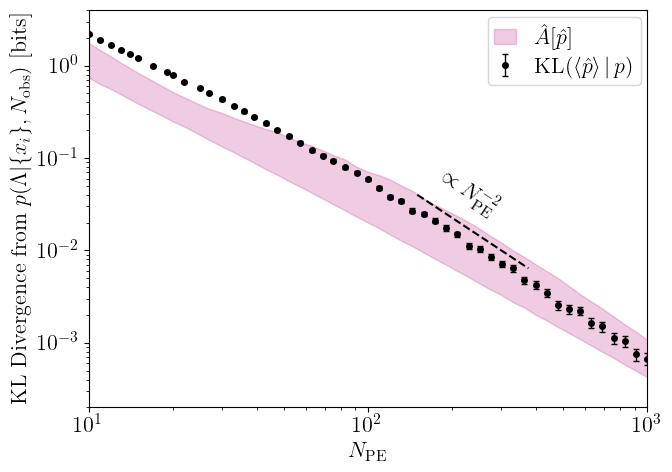

In [ ]:
import jax
from jax.scipy.special import logsumexp as LSE
import jax.numpy as jnp
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '4'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.95'

nsample = 10000
npes = np.array(
    [10,  11,  12,  13,  14,  15,  17,  19,  20,  22,  25,  27,  30,  33,
     36,  39,  43,  47,  52,  57,  63,  69,  75,  83,  91, 100, 109,
     120, 131, 144, 158, 173, 190, 208, 229, 251, 275, 301, 331, 363,
     398, 436, 478, 524, 575, 630, 691, 758, 831, 912, 1000]
     )
larger_npe = []
npes = tqdm(npes)
fig, axes = plt.subplots(nrows=1, sharex=False, figsize=(7,5))

ndim = 1
noise = 1
ax = axes
xlims = [1e1, 1e3]
ylims = [2e-4, 4]
    
Nobs = 100
acc_npe = []
mean_kls = []
kls = []
accu_stats = []
unc_mean_kls = []
success = 0
for npe in npes:
    npes.set_description(f'Number succeed: {success}, NPE: {npe}')
    try:
        with open(f'../../../data/one_dimensional_data/noise{int(noise)}p{int((noise - int(noise))*10)}_Nobs{Nobs}_nsample{nsample}_posteriors/npe_{npe}.pkl', 'rb') as ff:
            dictionary = pkl.load(ff)
    except:
        continue
    acc_npe.append(npe)
    success += 1
    posteriors = jnp.array(dictionary['posteriors'][:,:2,...])
    accu_stats.append(jnp.trapezoid(jnp.exp(posteriors[:,0])*dictionary['corrections'][:,1]**2, x=sigma, axis=-1) / 2 / np.log(2))
    sigma = dictionary['sigmas']
    analytical_posterior = dictionary['analytic_posterior']
    kl = dictionary['KL'][...,:2]
    mean_post = LSE(posteriors, axis=0) - jnp.log(posteriors.shape[0])
    f = lambda index: LSE(posteriors[...,None,index] + posteriors - mean_post[None,...,index,None] - mean_post[None,...] - jnp.log(posteriors.shape[0] - 1) - jnp.log(posteriors.shape[0]), axis=0)
    log_second_moment_post = jax.lax.map(f, jnp.arange(posteriors.shape[-1]))
    cov_post = (jnp.exp(log_second_moment_post) - 1 / (posteriors.shape[0] - 1))
    
    mean_kl = jnp.trapezoid(jnp.exp(analytical_posterior) * (analytical_posterior - mean_post), x=sigma, axis=-1) / np.log(2)
    unc_mean_kl = jnp.trapezoid(jnp.exp(analytical_posterior)[None,None,:] * cov_post, x=sigma, axis=-1)
    unc_mean_kl = jnp.trapezoid(jnp.exp(analytical_posterior)[:,None] * unc_mean_kl, x=sigma, axis=0) / np.log(2)**2
    mean_kls.append(mean_kl)
    unc_mean_kls.append(np.sqrt(np.abs(unc_mean_kl)+1e-10))
    kls.append(kl[:nsample,:])
accu_stats = np.array(accu_stats)
mean_kls = np.array(mean_kls)
kls = np.array(kls)
unc_mean_kls = np.array(unc_mean_kls)
print(kls.shape, mean_kls.shape)

# ax.fill_between(acc_npe, np.percentile(kls[:,:,0], 5, axis=1), np.percentile(kls[:,:,0], 95, axis=1), color=colors[0], alpha=0.2, label=f'KL$(\hat{{p}}\,|\,p)$')
ax.fill_between(acc_npe, np.percentile(accu_stats, 5, axis=1), np.percentile(accu_stats, 95, axis=1), color=colors[1], alpha=0.2, label=f'$\hat{{A}}[\hat{{p}}]$')
ax.errorbar(acc_npe, mean_kls[:,0], yerr=2*unc_mean_kls[:,0], color=colors[0], linestyle='', marker='o', markersize=4, capsize=2, linewidth=1, label=f'KL$(\langle\hat{{p}}\\rangle\,|\,p)$')
# ax.errorbar(acc_npe, true_precision[:,0], yerr=2*unc_mean_kls[:,0], color=colors[0], linestyle='', marker='o', markersize=4, capsize=2, linewidth=1, label=f'$\\langle\\textrm{{KL}}(\hat{{p}}\,|\, \\langle\hat{{p}}\\rangle)\\rangle$')
# ax.fill_between(acc_npe, np.percentile(mean_vars[:,:,0], 5, axis=1), np.percentile(mean_vars[:,:,0], 95, axis=1), color=colors[2], alpha=0.2, label=f'$\int d\Lambda \hat{{\sigma}}^2(\Lambda) \hat{{p}}(\Lambda)$') # f'$\\langle \hat{{\sigma}}^2\\rangle_{{\hat{{p}}_{{{subscript[ii]}}}}}$'

xs = np.linspace(200,500,30)
# ax.plot(xs, 6e-4 * (xs/xs[0])**(-4), 'k--')
ax.plot(0.75*xs, 9e-2*(1.5*xs/xs[0])**(-2), 'k--')

ax.set_xlim([xlims[0], xlims[1]])
ax.set_yscale('log')
ax.set_xscale('log')
a, b = ax.get_xlim()
xsize, ysize = fig.get_size_inches()
xscale = np.log(b/a) * xsize
a, b = ax.get_ylim()
yscale = np.log(b/a) * ysize

# CurvedText(x=xs, y=3*6e-4 * (xs[3:]/xs[0])**(-4), text="$\propto N_{\\rm PE}^{-4}$", ha='center', va='bottom', axes=ax, latex=True) #""
CurvedText(x=0.75*xs[3:], y=2*9e-2*(1.5*xs[3:]/xs[0])**(-2), text="$\propto N_{\\rm PE}^{-2}$", ha='center', va='bottom', axes=ax, latex=True) #"$\propto N_{\\rm PE}^{-2}$"

ax.set_yticks(np.logspace(-5,1,7))
ax.set_yticks(np.outer(np.linspace(0.1,0.9,9),np.logspace(-5,1,7)).flatten(), minor=True)
ax.set_ylim([ylims[0], ylims[1]])

plt.legend(frameon=True, loc='upper right', ncols=1,  borderpad=0.3, labelspacing=0.3, columnspacing=0.5, handlelength=1, borderaxespad=0.3) 

plt.ylabel('KL Divergence from $p(\\Lambda|\{x_i\}, N_{\\rm obs})$ [bits]')
plt.xlabel('$N_{\\rm PE}$')

plt.tight_layout()
# plt.savefig('../../../draft/plots/larger_KL_npe_noise1.pdf')
plt.show()


Number succeed: 50, NPE: 1000: 100%|██████████| 51/51 [01:23<00:00,  1.63s/it]


(51, 10000, 2) (51, 2)


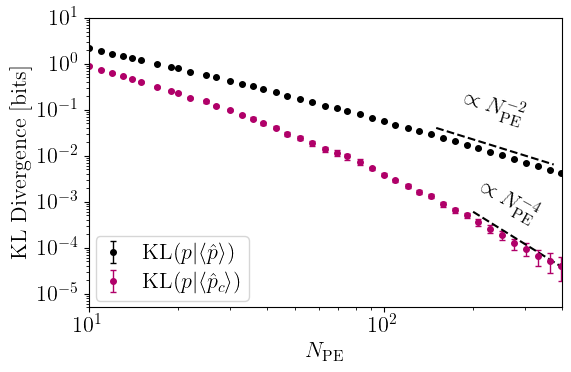

In [13]:
import jax
from jax.scipy.special import logsumexp as LSE
import jax.numpy as jnp
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '4'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.95'

nsample = 10000
larger_nsample = 100000
npes = np.array(
    [10,  11,  12,  13,  14,  15,  17,  19,  20,  22,  25,  27,  30,  33,
     36,  39,  43,  47,  52,  57,  63,  69,  75,  83,  91, 100, 109,
     120, 131, 144, 158, 173, 190, 208, 229, 251, 275, 301, 331, 363,
     398]
     )
npes = np.array(
    [10,  11,  12,  13,  14,  15,  17,  19,  20,  22,  25,  27,  30,  33,
     36,  39,  43,  47,  52,  57,  63,  69,  75,  83,  91, 100, 109,
     120, 131, 144, 158, 173, 190, 208, 229, 251, 275, 301, 331, 363,
     398, 436, 478, 524, 575, 630, 691, 758, 831, 912, 1000]
     )
larger_npe = npes[24:-10]
# larger_npe = []
npes = tqdm(npes)
fig, axes = plt.subplots(nrows=1, sharex=False, figsize=(6,4))

ndim = 1
noise = 1
ax = axes
xlims = [1e1, 4e2]
ylims = [5e-6, 1e1]
    
Nobs = 100
acc_npe = []
mean_kls = []
kls = []
unc_mean_kls = []
success = 0
for npe in npes:
    npes.set_description(f'Number succeed: {success}, NPE: {npe}')
    if npe in larger_npe:
        try:
            with open(f'../../../data/one_dimensional_data/noise{int(noise)}p{int((noise - int(noise))*10)}_Nobs{Nobs}_nsample{larger_nsample}_posteriors/npe_{npe}.pkl', 'rb') as ff:
                dictionary = pkl.load(ff)
        except:
            continue
    else:
        try:
            with open(f'../../../data/one_dimensional_data/noise{int(noise)}p{int((noise - int(noise))*10)}_Nobs{Nobs}_nsample{nsample}_posteriors/npe_{npe}.pkl', 'rb') as ff:
                dictionary = pkl.load(ff)
        except:
            continue
    acc_npe.append(npe)
    success += 1
    posteriors = jnp.array(dictionary['posteriors'][:,:2,...])
    # so we can plot both on top
    # print(posteriors.shape)
    sigma = dictionary['sigmas']
    analytical_posterior = dictionary['analytic_posterior']
    kl = dictionary['KL'][...,:2]
    
    mean_post = LSE(posteriors, axis=0) - jnp.log(posteriors.shape[0])
    # log_second_moment_post =jnp.array(
    #     [LSE(posteriors[...,None,index] + posteriors - mean_post[None,...,index,None] - mean_post[None,...] - jnp.log(posteriors.shape[0] - 1) - jnp.log(posteriors.shape[0]), axis=0)
    #     for index in tqdm(range(posteriors.shape[-1]))])
    f = lambda index: LSE(posteriors[...,None,index] + posteriors - mean_post[None,...,index,None] - mean_post[None,...] - jnp.log(posteriors.shape[0] - 1) - jnp.log(posteriors.shape[0]), axis=0)
    log_second_moment_post = jax.lax.map(f, jnp.arange(posteriors.shape[-1]))
    # log_second_moment_post = LSE(2*posteriors - 2*mean_post[None,None,...] - np.log(nsample/4 - 1) - np.log(nsample/4), axis=0)
    cov_post = (jnp.exp(log_second_moment_post) - 1 / (posteriors.shape[0] - 1))
    # print(var_post)
    # print(posteriors.shape[0])
    mean_kl = jnp.trapezoid(jnp.exp(analytical_posterior) * (analytical_posterior - mean_post), x=sigma, axis=-1) / np.log(2)
    unc_mean_kl = jnp.trapezoid(jnp.exp(analytical_posterior)[None,None,:] * cov_post, x=sigma, axis=-1)
    unc_mean_kl = jnp.trapezoid(jnp.exp(analytical_posterior)[:,None] * unc_mean_kl, x=sigma, axis=0) / np.log(2)**2
    mean_kls.append(mean_kl)
    unc_mean_kls.append(np.sqrt(np.abs(unc_mean_kl)+1e-10))
    kls.append(kl[:nsample,:])
mean_kls = np.array(mean_kls)
kls = np.array(kls)
unc_mean_kls = np.array(unc_mean_kls)
print(kls.shape, mean_kls.shape)
subscript = ['', 'c']
# for ii, color in enumerate(colors[:2]):
#     ax.fill_between(acc_npe, np.percentile(kls[:,:,ii], 5, axis=1), np.percentile(kls[:,:,ii], 95, axis=1), color=color, alpha=0.2, label=f'KL$(p|\hat{{p}}_{{{subscript[ii]}}})$')
for ii, color in enumerate(colors[:2]):
    ax.errorbar(acc_npe, mean_kls[:,ii], yerr=2*unc_mean_kls[:,ii], color=color, linestyle='', marker='o', markersize=4, capsize=2, linewidth=1, label=f'KL$(p|\langle\hat{{p}}_{{{subscript[ii]}}}\\rangle)$')
    # ax.scatter(np.ones(3), np.zeros(3), marker='o', color=color, label=f'KL$(p||\langle\hat{{p}}_{{{subscript[ii]}}}\\rangle)$')
xs = np.linspace(200,500,30)
ax.plot(xs, 6e-4 * (xs/xs[0])**(-4), 'k--')
ax.plot(0.75*xs, 9e-2*(1.5*xs/xs[0])**(-2), 'k--')

ax.set_xlim([xlims[0], xlims[1]])
ax.set_yscale('log')
ax.set_xscale('log')
a, b = ax.get_xlim()
xsize, ysize = fig.get_size_inches()
xscale = np.log(b/a) * xsize
a, b = ax.get_ylim()
yscale = np.log(b/a) * ysize

CurvedText(x=xs, y=5*6e-4 * (xs[3:]/xs[0])**(-4), text="$\propto N_{\\rm PE}^{-4}$", ha='center', va='bottom', axes=ax, latex=True) #""
CurvedText(x=0.75*xs[3:], y=4*9e-2*(1.5*xs[3:]/xs[0])**(-2), text="$\propto N_{\\rm PE}^{-2}$", ha='center', va='bottom', axes=ax, latex=True) #"$\propto N_{\\rm PE}^{-2}$"

ax.set_yticks(np.logspace(-5,1,7))
ax.set_yticks(np.outer(np.linspace(0.1,0.9,9),np.logspace(-5,1,7)).flatten(), minor=True)
ax.set_ylim([ylims[0], ylims[1]])

# ax.fill_between(acc_npe, np.percentile(mc_arr, 5, axis=1), np.percentile(mc_arr, 95, axis=1), color=color, alpha=0.2)
    # ax.grid(visible=True)

# plt.legend(frameon=False, borderpad=0.1, labelspacing=0.5, ncols=2, columnspacing=0.5, handlelength=1)
plt.legend(loc='lower left', frameon=True, borderpad=0.3, labelspacing=0.3, columnspacing=0.5, handlelength=1, borderaxespad=0.3)
# plt.ylabel('KL$(\langle \hat{p}\\rangle || p)$ [bits]')
plt.ylabel('KL Divergence [bits]')
plt.xlabel('$N_{\\rm PE}$')

plt.tight_layout()
plt.savefig('../../../draft/plots/larger_KL_npe_noise1.pdf')
plt.show()


(100, 10, 1000)
(100, 10, 1000)
(100, 10, 1000)


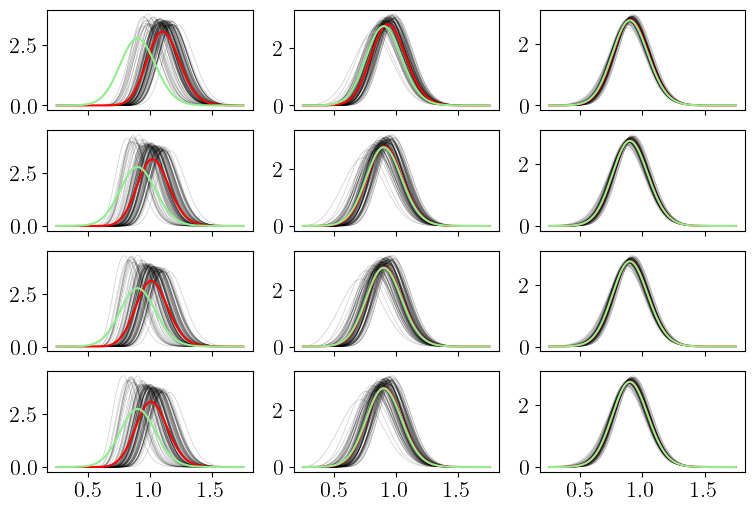

In [4]:
npes = [10,100,1000]
noise = 1
Nobs = 100
nsample = 100
fig, axes = plt.subplots(nrows=4, ncols=len(npes), sharex=True, figsize=(9,6))
for jj, npe in enumerate(npes):
    ax = axes[:,jj]
    with open(f'../../../data/one_dimensional_data/noise{int(noise)}p{int((noise - int(noise))*10)}_Nobs{Nobs}_nsample{nsample}_posteriors/npe_{npe}.pkl', 'rb') as ff:
        dictionary = pkl.load(ff)
        # 'KL' 'posteriors' 'corrections' 'mean_covariance' 'mean_variance' 'evidence' 'minimum_effective_samples' 'mus' 'sigmas' 'analytic_posterior'
    posteriors = dictionary['posteriors']
    print(posteriors.shape)
    sigma = dictionary['sigmas']
    analytical_posterior = dictionary['analytic_posterior']
    
    for ii, a in enumerate(ax):
        p = posteriors[:,ii]
        corr = posteriors[:,1] - posteriors[:,0]
        for post in p:
            a.plot(sigma, np.exp(post), 'k-', linewidth=.5, alpha=0.2)
        a.plot(sigma, np.mean(np.exp(p), axis=0), 'r-')
        a.plot(sigma, np.exp(analytical_posterior), color='lightgreen')
        
plt.show()

Number succeed: 41, NPE: 1000: 100%|██████████| 50/50 [00:33<00:00,  1.47it/s]


(41, 10000, 2) (41, 2)


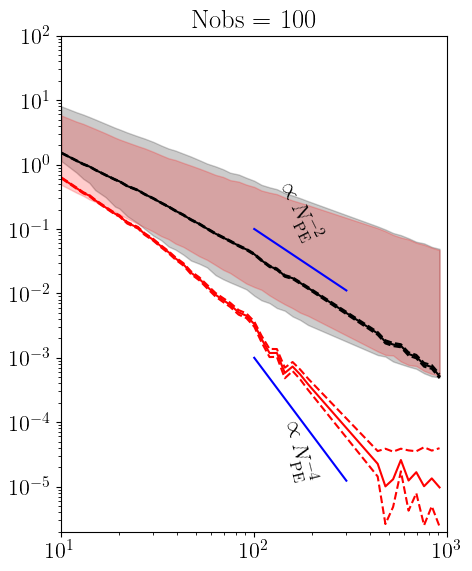

In [ ]:
import jax
from jax.scipy.special import logsumexp as LSE
import jax.numpy as jnp
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '4'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.95'

nsample = 10000
npes = np.unique(np.logspace(1,3,51, dtype=int))
npes = tqdm(npes)
fig, axes = plt.subplots(nrows=1, sharex=False, figsize=(5,6))
# Nobs = 100
Nobs_list = [100]
ndim = 1
noise = 1
colors = ['k', 'r']
ax = axes
xlims = [1e1, 1e3]
ylims = [2e-6, 1e2]

# for aleph in [0,1]:
if True:
    
    Nobs = Nobs_list[0]
    ax.set_title(f'Nobs = {Nobs}')
    acc_npe = []
    mean_kls = []
    kls = []
    unc_mean_kls = []
    success = 0
    for npe in npes:
        npes.set_description(f'Number succeed: {success}, NPE: {npe}')
        try:
            with open(f'../../../data/one_dimensional_data/noise{int(noise)}p{int((noise - int(noise))*10)}_Nobs{Nobs}_nsample{nsample}_posteriors/npe_{npe}.pkl', 'rb') as ff:
                dictionary = pkl.load(ff)
                
        except:
            continue
        acc_npe.append(npe)
        success += 1
        posteriors = jnp.array(dictionary['posteriors'][:,:2,...])
        # so we can plot both on top
        # print(posteriors.shape)
        sigma = dictionary['sigmas']
        analytical_posterior = dictionary['analytic_posterior']
        kl = dictionary['KL'][...,:2]
        
        mean_post = LSE(posteriors, axis=0) - jnp.log(posteriors.shape[0])
        # log_second_moment_post =jnp.array(
        #     [LSE(posteriors[...,None,index] + posteriors - mean_post[None,...,index,None] - mean_post[None,...] - jnp.log(posteriors.shape[0] - 1) - jnp.log(posteriors.shape[0]), axis=0)
        #     for index in tqdm(range(posteriors.shape[-1]))])
        f = lambda index: LSE(posteriors[...,None,index] + posteriors - mean_post[None,...,index,None] - mean_post[None,...] - jnp.log(posteriors.shape[0] - 1) - jnp.log(posteriors.shape[0]), axis=0)
        log_second_moment_post = jax.lax.map(f, jnp.arange(posteriors.shape[-1]))
        # log_second_moment_post = LSE(2*posteriors - 2*mean_post[None,None,...] - np.log(nsample/4 - 1) - np.log(nsample/4), axis=0)
        cov_post = (jnp.exp(log_second_moment_post) - 1 / (posteriors.shape[0] - 1))
        # print(var_post)
        # print(posteriors.shape[0])
        mean_kl = jnp.trapezoid(jnp.exp(analytical_posterior) * (analytical_posterior - mean_post), x=sigma, axis=-1)
        unc_mean_kl = jnp.trapezoid(jnp.exp(analytical_posterior)[None,None,:] * cov_post, x=sigma, axis=-1)
        unc_mean_kl = jnp.trapezoid(jnp.exp(analytical_posterior)[:,None] * unc_mean_kl, x=sigma, axis=0)
        mean_kls.append(mean_kl)
        unc_mean_kls.append(np.sqrt(np.abs(unc_mean_kl)+1e-10))
        kls.append(kl)
    mean_kls = np.array(mean_kls)
    kls = np.array(kls)
    unc_mean_kls = np.array(unc_mean_kls)
    print(kls.shape, mean_kls.shape)
    for ii, color in enumerate(colors):
        ax.fill_between(acc_npe, np.percentile(kls[:,:,ii], 5, axis=1), np.percentile(kls[:,:,ii], 95, axis=1), color=color, alpha=0.2)
        ax.plot(acc_npe, mean_kls[:,ii], color=color)
        ax.plot(acc_npe, mean_kls[:,ii]*np.exp(unc_mean_kls[:,ii]/mean_kls[:,ii]), color=color, linestyle='dashed')
        ax.plot(acc_npe, mean_kls[:,ii]*np.exp(-unc_mean_kls[:,ii]/mean_kls[:,ii]), color=color, linestyle='dashed')
        

    xs = np.linspace(100,300,100)
    ax.plot(xs, 1e-3 * (xs/100)**(-4), color='b')
    ax.plot(xs, 1e-1 * (xs/100)**(-2), color='b')

    ax.set_xlim([xlims[0], xlims[1]])
    ax.set_ylim([ylims[0], ylims[1]])
    ax.set_yscale('log')
    ax.set_xscale('log')
    a, b = ax.get_xlim()
    xsize, ysize = fig.get_size_inches()
    xscale = np.log(b/a) * xsize
    a, b = ax.get_ylim()
    yscale = np.log(b/a) * ysize
    
    ax.text(3, 1.2, "$\propto N_{\\rm PE}^{-4}$", rotation=-np.arctan(4)*180/np.pi, ha='center', va='center', transform=fig.dpi_scale_trans, transform_rotates_text=True, rotation_mode='anchor')
    ax.text(3, 3.6, "$\propto N_{\\rm PE}^{-2}$", rotation=-np.arctan(2)*180/np.pi, ha='center', va='center', transform=fig.dpi_scale_trans, transform_rotates_text=True, rotation_mode='anchor')

    # ax.fill_between(acc_npe, np.percentile(mc_arr, 5, axis=1), np.percentile(mc_arr, 95, axis=1), color=color, alpha=0.2)
    # ax.grid(visible=True)
    
plt.tight_layout()
plt.show()


In [8]:
posteriors.shape

(5000, 2, 1000)

so the estimation of the variance is a bit off, since both the kls look basically the same

In [10]:
cov_post.shape

(1000, 2, 1000)

(100, 3, 1000)
(100, 3, 1000)
(100, 3, 1000)


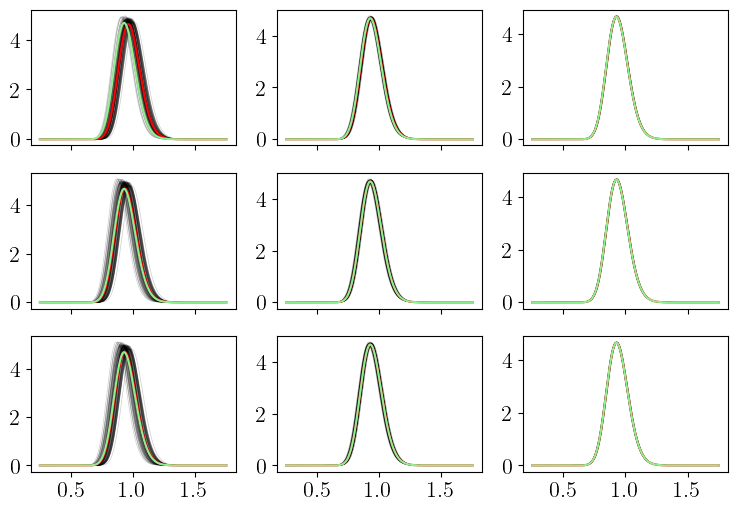

In [12]:
npes = [10,100,1000]
noise = 0.5
Nobs = 100
nsample = 100

fig, axes = plt.subplots(nrows=3, ncols=len(npes), sharex=True, figsize=(9,6))
for jj, npe in enumerate(npes):
    ax = axes[:,jj]
    with open(f'../../../data/one_dimensional_data/noise{int(noise)}p{int((noise - int(noise))*10)}_Nobs{Nobs}_nsample{nsample}_posteriors/npe_{npe}.pkl', 'rb') as ff:
        dictionary = pkl.load(ff)
        # 'KL' 'posteriors' 'corrections' 'mean_covariance' 'mean_variance' 'evidence' 'minimum_effective_samples' 'mus' 'sigmas' 'analytic_posterior'
    posteriors = dictionary['posteriors']
    print(posteriors.shape)
    sigma = dictionary['sigmas']
    analytical_posterior = dictionary['analytic_posterior']
    
    for ii, a in enumerate(ax):
        p = posteriors[:,ii]
        corr = posteriors[:,1] - posteriors[:,0]
        for post in p:
            a.plot(sigma, np.exp(post), 'k-', linewidth=.5, alpha=0.2)
        a.plot(sigma, np.mean(np.exp(p), axis=0), 'r-')
        a.plot(sigma, np.exp(analytical_posterior), color='lightgreen')
        
plt.show()

(100, 10, 1000)
(100, 10, 1000)
(100, 10, 1000)


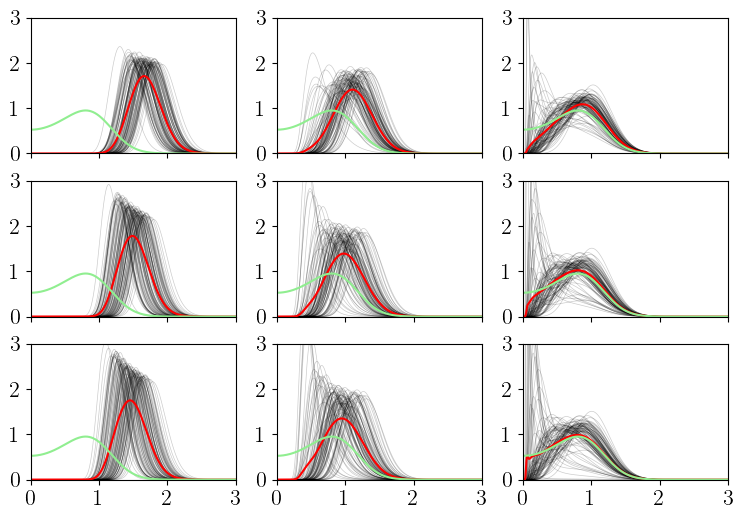

In [10]:
npes = [10,100,1000]
noise = 2
Nobs = 100
nsample = 100
fig, axes = plt.subplots(nrows=3, ncols=len(npes), sharex=True, figsize=(9,6))
for jj, npe in enumerate(npes):
    ax = axes[:,jj]
    with open(f'../../../data/one_dimensional_data/noise{int(noise)}p{int((noise - int(noise))*10)}_Nobs{Nobs}_nsample{nsample}_posteriors/npe_{npe}.pkl', 'rb') as ff:
        dictionary = pkl.load(ff)
        # 'KL' 'posteriors' 'corrections' 'mean_covariance' 'mean_variance' 'evidence' 'minimum_effective_samples' 'mus' 'sigmas' 'analytic_posterior'
    posteriors = dictionary['posteriors']
    print(posteriors.shape)
    sigma = dictionary['sigmas']
    analytical_posterior = dictionary['analytic_posterior']
    
    for ii, a in enumerate(ax):
        if ii == 2:
            ii = 9
        p = posteriors[:,ii]
        corr = posteriors[:,1] - posteriors[:,0]
        for post in p:
            a.plot(sigma, np.exp(post), 'k-', linewidth=.5, alpha=0.2)
        a.plot(sigma, np.mean(np.exp(p), axis=0), 'r-')
        a.plot(sigma, np.exp(analytical_posterior), color='lightgreen')
        a.set_ylim([0,3])
        a.set_xlim([0,3])
        
plt.show()

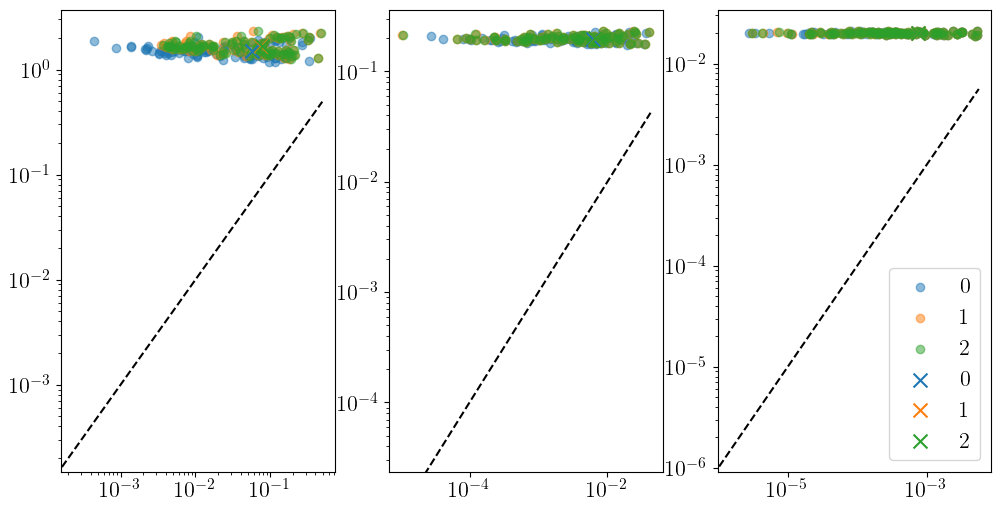

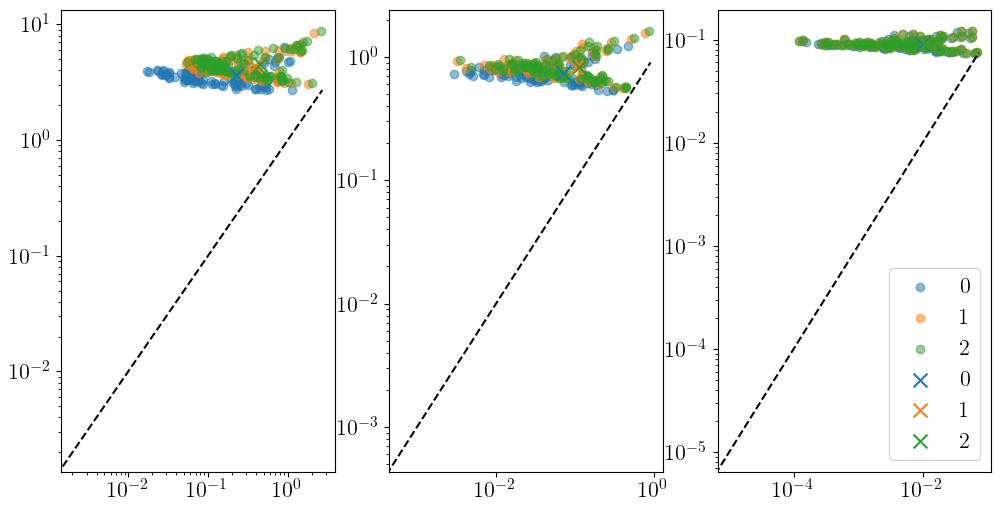

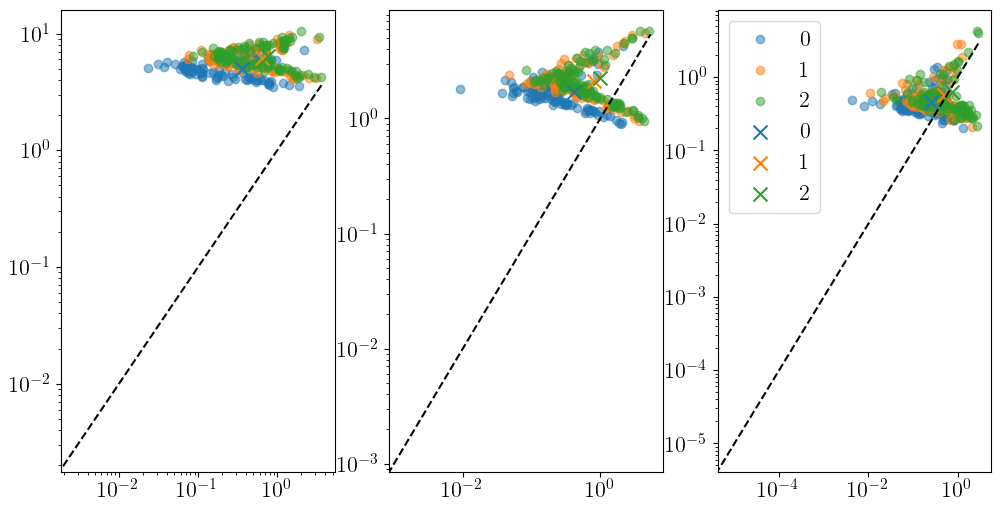

In [14]:
npes = [10,100,1000]
Nobs = 100
nsample = 100

for noise in [0.5, 1.0, 2.0]:
    fig, ax = plt.subplots(nrows=1, ncols=len(npes), figsize=(12,6))
    for jj, npe in enumerate(npes):
        a = ax[jj]
        
        with open(f'../../../data/one_dimensional_data/noise{int(noise)}p{int((noise - int(noise))*10)}_Nobs{Nobs}_nsample{nsample}_posteriors/npe_{npe}.pkl', 'rb') as ff:
            dictionary = pkl.load(ff)
            # 'KL' 'posteriors' 'corrections' 'mean_covariance' 'mean_variance' 'evidence' 'minimum_effective_samples' 'mus' 'sigmas' 'analytic_posterior'
        posteriors = dictionary['posteriors'] # (Nrandom, 10, Nsigma)
        mean_posterior = LSE(posteriors, axis=0) - jnp.log(posteriors.shape[0])
        mean_posterior = mean_posterior[None,...]
        KL = jnp.trapezoid(jnp.exp(mean_posterior) * (mean_posterior - posteriors), x=dictionary['sigmas'], axis=-1) / np.log(2)
        
        mean_cov = dictionary['mean_covariance'] # (Nrandom, 10)
        mean_var = jnp.trapezoid(jnp.exp(posteriors) * dictionary['mean_variance'][:,None,:], x=dictionary['sigmas'], axis=-1)
        exp_KL = 0.5*mean_var[:,:-1] / np.log(2)

        log_mean_exp_half_var = LSE(posteriors + 0.5*dictionary['mean_variance'][:,None,:], axis=-1) + jnp.log(dictionary['sigmas'][1] - dictionary['sigmas'][0])
        for ii in range(3):
            a.scatter(KL[:,ii], exp_KL[:,ii], alpha=0.5, label=f'{ii}')
        for ii in range(3):
            a.scatter(np.mean(KL[:,ii]), np.mean(exp_KL[:,ii]), marker='x', s=100, alpha=1, color='C'+str(ii), label=f'{ii}')
        
        xlo, xhi = a.get_xlim()
        a.plot(jnp.linspace(xlo, xhi, 1000), jnp.linspace(xlo, xhi, 1000), 'k--')
        a.set_xscale('log')
        a.set_yscale('log')
    a.legend()
    plt.show()

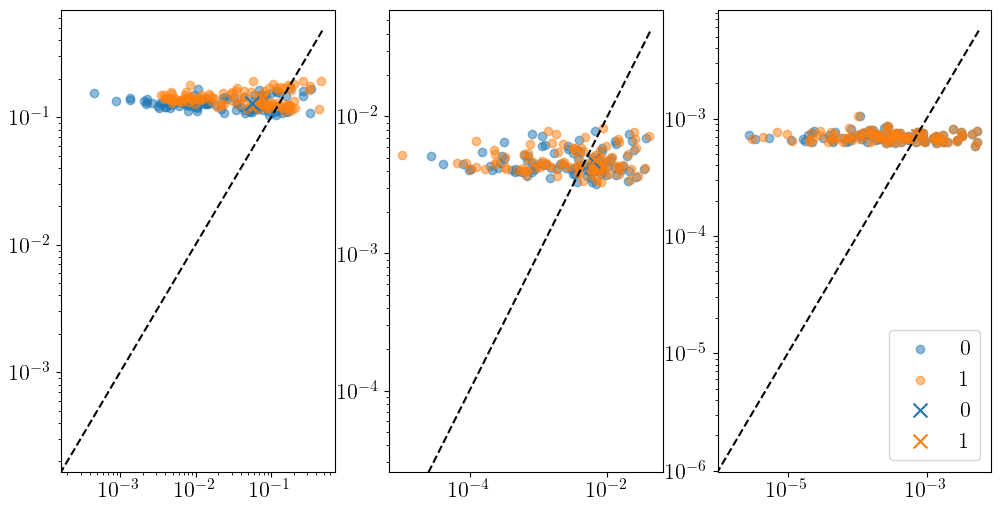

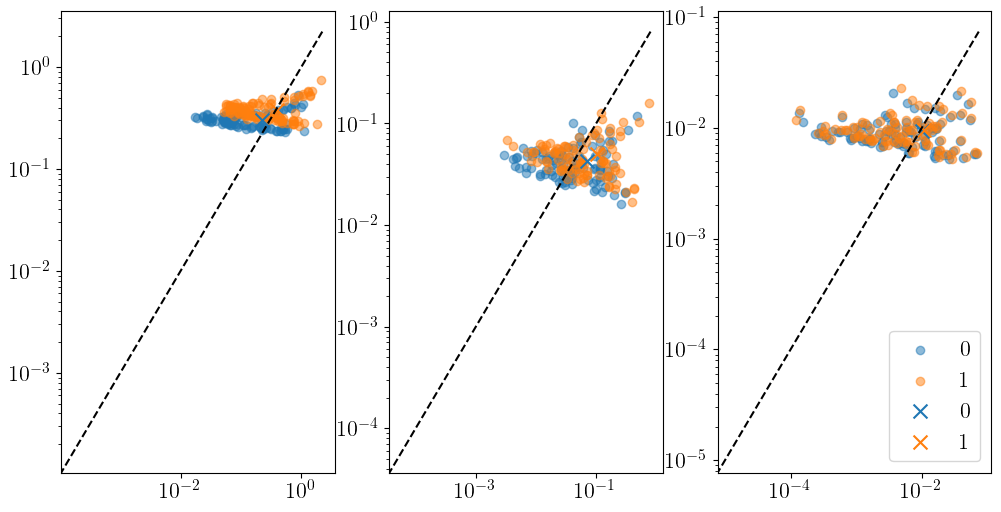

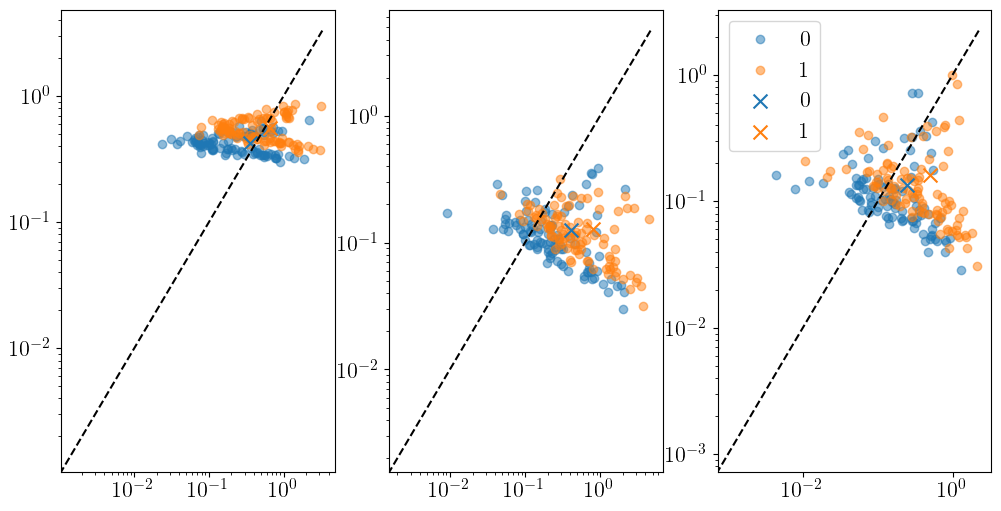

In [20]:
npes = [10,100,1000]
Nobs = 100
nsample = 100

for noise in [0.5, 1.0, 2.0]:
    fig, ax = plt.subplots(nrows=1, ncols=len(npes), figsize=(12,6))
    for jj, npe in enumerate(npes):
        a = ax[jj]
        
        with open(f'../../../data/one_dimensional_data/noise{int(noise)}p{int((noise - int(noise))*10)}_Nobs{Nobs}_nsample{nsample}_posteriors/npe_{npe}.pkl', 'rb') as ff:
            dictionary = pkl.load(ff)
            # 'KL' 'posteriors' 'corrections' 'mean_covariance' 'mean_variance' 'evidence' 'minimum_effective_samples' 'mus' 'sigmas' 'analytic_posterior'
        posteriors = dictionary['posteriors'] # (Nrandom, 10, Nsigma)
        mean_posterior = LSE(posteriors, axis=0) - jnp.log(posteriors.shape[0])
        mean_posterior = mean_posterior[None,...]
        KL = jnp.trapezoid(jnp.exp(mean_posterior) * (mean_posterior - posteriors), x=dictionary['sigmas'], axis=-1) / np.log(2)
        
        mean_cov = dictionary['mean_covariance'] # (Nrandom, 10)
        mean_var = jnp.trapezoid(jnp.exp(posteriors) * dictionary['mean_variance'][:,None,:], x=dictionary['sigmas'], axis=-1)
        exp_KL = np.abs(0.5*(mean_var[:,:-1] - mean_cov[:,1:]) / np.log(2))
        
        log_mean_exp_half_var = LSE(posteriors + 0.5*dictionary['mean_variance'][:,None,:], axis=-1) + jnp.log(dictionary['sigmas'][1] - dictionary['sigmas'][0])
        for ii in range(2):
            a.scatter(KL[:,ii], exp_KL[:,ii], alpha=0.5, label=f'{ii}')
        for ii in range(2):
            a.scatter(np.mean(KL[:,ii]), np.mean(exp_KL[:,ii]), marker='x', s=100, alpha=1, color='C'+str(ii), label=f'{ii}')
        
        xlo, xhi = a.get_xlim()
        a.plot(jnp.linspace(xlo, xhi, 1000), jnp.linspace(xlo, xhi, 1000), 'k--')
        a.set_xscale('log')
        a.set_yscale('log')
    a.legend()
    plt.show()

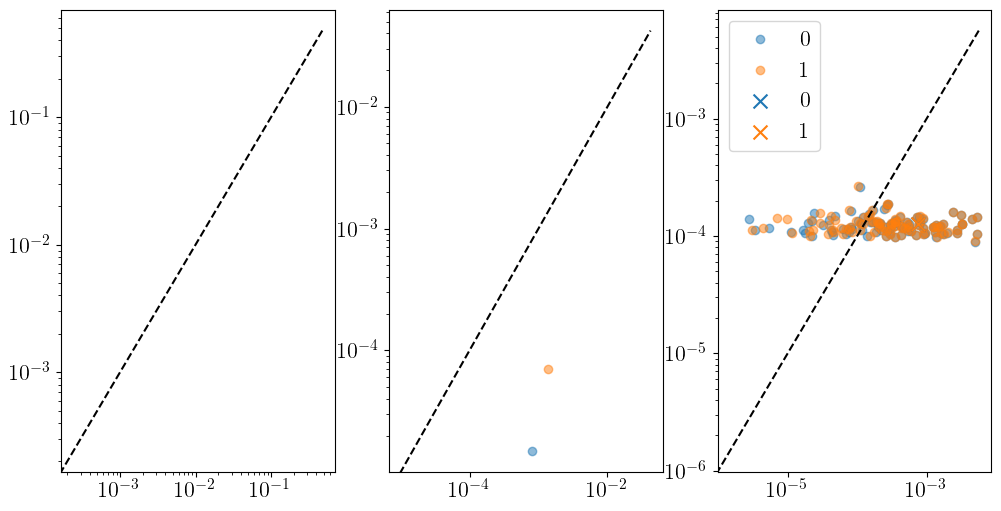

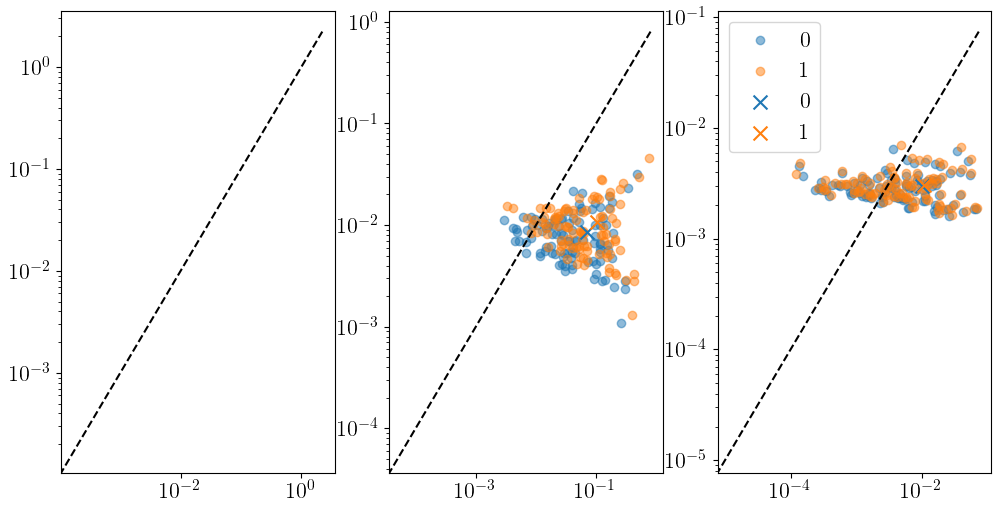

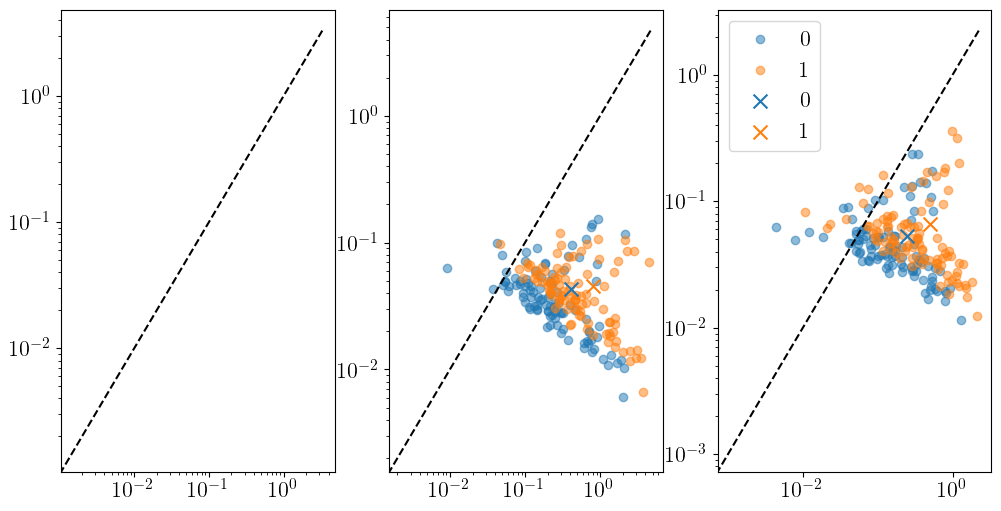

In [22]:
npes = [10,100,1000]
Nobs = 100
nsample = 100

for noise in [0.5, 1.0, 2.0]:
    fig, ax = plt.subplots(nrows=1, ncols=len(npes), figsize=(12,6))
    for jj, npe in enumerate(npes):
        a = ax[jj]
        
        with open(f'../../../data/one_dimensional_data/noise{int(noise)}p{int((noise - int(noise))*10)}_Nobs{Nobs}_nsample{nsample}_posteriors/npe_{npe}.pkl', 'rb') as ff:
            dictionary = pkl.load(ff)
            # 'KL' 'posteriors' 'corrections' 'mean_covariance' 'mean_variance' 'evidence' 'minimum_effective_samples' 'mus' 'sigmas' 'analytic_posterior'
        posteriors = dictionary['posteriors'] # (Nrandom, 10, Nsigma)
        mean_posterior = LSE(posteriors, axis=0) - jnp.log(posteriors.shape[0])
        mean_posterior = mean_posterior[None,...]
        KL = jnp.trapezoid(jnp.exp(mean_posterior) * (mean_posterior - posteriors), x=dictionary['sigmas'], axis=-1) / np.log(2)
        
        mean_cov = dictionary['mean_covariance'] # (Nrandom, 10)
        mean_var = jnp.trapezoid(jnp.exp(posteriors) * np.sqrt(dictionary['mean_variance'][:,None,:]), x=dictionary['sigmas'], axis=-1)
        exp_KL = 0.5*(mean_var[:,:-1]**2 - mean_cov[:,1:]) / np.log(2)
        
        log_mean_exp_half_var = LSE(posteriors + 0.5*dictionary['mean_variance'][:,None,:], axis=-1) + jnp.log(dictionary['sigmas'][1] - dictionary['sigmas'][0])
        for ii in range(2):
            a.scatter(KL[:,ii], exp_KL[:,ii], alpha=0.5, label=f'{ii}')
        for ii in range(2):
            a.scatter(np.mean(KL[:,ii]), np.mean(exp_KL[:,ii]), marker='x', s=100, alpha=1, color='C'+str(ii), label=f'{ii}')
        
        xlo, xhi = a.get_xlim()
        a.plot(jnp.linspace(xlo, xhi, 1000), jnp.linspace(xlo, xhi, 1000), 'k--')
        a.set_xscale('log')
        a.set_yscale('log')
    a.legend()
    plt.show()

(100, 10, 1000)
(100, 10, 1000)
(100, 10, 1000)


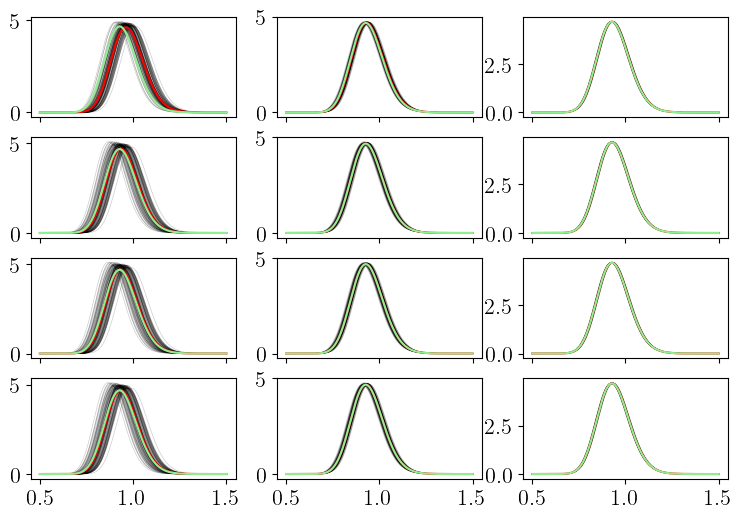

In [ ]:
npes = [10,100,1000]
noise = 0.5
Nobs = 100
nsample = 100
fig, axes = plt.subplots(nrows=4, ncols=len(npes), sharex=True, figsize=(9,6))
for jj, npe in enumerate(npes):
    ax = axes[:,jj]
    with open(f'../../../data/one_dimensional_data/noise{int(noise)}p{int((noise - int(noise))*10)}_Nobs{Nobs}_nsample{nsample}_posteriors/npe_{npe}.pkl', 'rb') as ff:
        dictionary = pkl.load(ff)
        # 'KL' 'posteriors' 'corrections' 'mean_covariance' 'mean_variance' 'evidence' 'minimum_effective_samples' 'mus' 'sigmas' 'analytic_posterior'
    posteriors = dictionary['posteriors']
    print(posteriors.shape)
    sigma = dictionary['sigmas']
    analytical_posterior = dictionary['analytic_posterior']
    
    for ii, a in enumerate(ax):
        p = posteriors[:,ii]
        corr = posteriors[:,1] - posteriors[:,0]
        for post in p:
            a.plot(sigma, np.exp(post), 'k-', linewidth=.5, alpha=0.2)
        a.plot(sigma, np.mean(np.exp(p), axis=0), 'r-')
        a.plot(sigma, np.exp(analytical_posterior), color='lightgreen')
        
plt.show()

[  2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19
  20  21  22  23  24  25  26  27  28  30  31  33  34  36  38  39  41  43
  45  47  50  52  54  57  60  63  66  69  72  75  79  83  87  91  95 100]


Number succeed: 53, NPE: 100: 100%|██████████| 54/54 [00:39<00:00,  1.36it/s]


(54, 10000, 2) (54, 2)


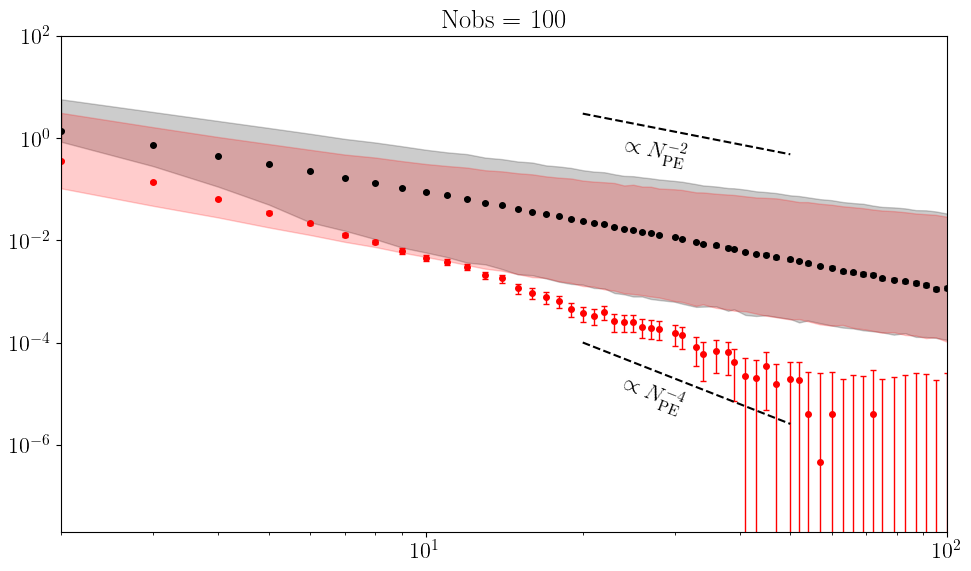

In [28]:
import jax
from jax.scipy.special import logsumexp as LSE
import jax.numpy as jnp
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '4'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.95'

nsample = 10000
# npes = np.unique(np.logspace(1,3,51, dtype=int))
npes = np.unique(np.logspace(0, 2, 101, dtype=int))[1:]
npes = np.append(npes, 24)
npes = np.sort(npes)
print(npes)
npes = tqdm(npes)
fig, axes = plt.subplots(nrows=1, sharex=False, figsize=(10,6))
# Nobs = 100
Nobs_list = [100]
ndim = 1
noise = 0.5
colors = ['k', 'r']
ax = axes
xlims = [2, 1e2]
ylims = [2e-8, 1e2]

# for aleph in [0,1]:
if True:
    
    Nobs = Nobs_list[0]
    ax.set_title(f'Nobs = {Nobs}')
    acc_npe = []
    mean_kls = []
    kls = []
    unc_mean_kls = []
    success = 0
    for npe in npes:
        npes.set_description(f'Number succeed: {success}, NPE: {npe}')
        try:
            with open(f'corrected_data/noise{int(noise)}p{int((noise - int(noise))*10)}_Nobs{Nobs}_nsample{nsample}_posteriors/npe_{npe}.pkl', 'rb') as ff:
                dictionary = pkl.load(ff)
                
        except:
            continue
        acc_npe.append(npe)
        success += 1
        posteriors = jnp.array(dictionary['posteriors'][:,:2,...])
        # so we can plot both on top
        # print(posteriors.shape)
        sigma = dictionary['sigmas']
        analytical_posterior = dictionary['analytic_posterior']
        kl = dictionary['KL'][...,:2]
        
        mean_post = LSE(posteriors, axis=0) - jnp.log(posteriors.shape[0])
        # log_second_moment_post =jnp.array(
        #     [LSE(posteriors[...,None,index] + posteriors - mean_post[None,...,index,None] - mean_post[None,...] - jnp.log(posteriors.shape[0] - 1) - jnp.log(posteriors.shape[0]), axis=0)
        #     for index in tqdm(range(posteriors.shape[-1]))])
        f = lambda index: LSE(posteriors[...,None,index] + posteriors - mean_post[None,...,index,None] - mean_post[None,...] - jnp.log(posteriors.shape[0] - 1) - jnp.log(posteriors.shape[0]), axis=0)
        log_second_moment_post = jax.lax.map(f, jnp.arange(posteriors.shape[-1]))
        # log_second_moment_post = LSE(2*posteriors - 2*mean_post[None,None,...] - np.log(nsample/4 - 1) - np.log(nsample/4), axis=0)
        cov_post = (jnp.exp(log_second_moment_post) - 1 / (posteriors.shape[0] - 1))
        # print(var_post)
        # print(posteriors.shape[0])
        mean_kl = jnp.trapezoid(jnp.exp(analytical_posterior) * (analytical_posterior - mean_post), x=sigma, axis=-1)
        unc_mean_kl = jnp.trapezoid(jnp.exp(analytical_posterior)[None,None,:] * cov_post, x=sigma, axis=-1)
        unc_mean_kl = jnp.trapezoid(jnp.exp(analytical_posterior)[:,None] * unc_mean_kl, x=sigma, axis=0)
        mean_kls.append(mean_kl)
        unc_mean_kls.append(np.sqrt(np.abs(unc_mean_kl)+1e-12))
        kls.append(kl)
    mean_kls = np.array(mean_kls)
    kls = np.array(kls)
    unc_mean_kls = np.array(unc_mean_kls)
    print(kls.shape, mean_kls.shape)
    for ii, color in enumerate(colors):
        ax.fill_between(acc_npe, np.percentile(kls[:,:,ii], 5, axis=1), np.percentile(kls[:,:,ii], 95, axis=1), color=color, alpha=0.2)
        # ax.plot(acc_npe, mean_kls[:,ii], color=color)
        ax.errorbar(acc_npe, mean_kls[:,ii], yerr=2*unc_mean_kls[:,ii], color=color, linestyle='', marker='o', markersize=4, capsize=2, linewidth=1)
        
    xs = np.linspace(20,50,30)
    ax.plot(xs, 1e-4 * (xs/20)**(-4), 'k--')
    ax.plot(xs, 3 * (xs/20)**(-2), 'k--')

    ax.set_xlim([xlims[0], xlims[1]])
    ax.set_ylim([ylims[0], ylims[1]])
    ax.set_yscale('log')
    ax.set_xscale('log')
    a, b = ax.get_xlim()
    xsize, ysize = fig.get_size_inches()
    xscale = np.log(b/a) * xsize
    a, b = ax.get_ylim()
    yscale = np.log(b/a) * ysize
    
    CurvedText(x=xs[3:], y=0.25*1e-4 * (xs[3:]/20)**(-4), text="$\propto N_{\\rm PE}^{-4}$", ha='center', va='bottom', axes=ax, latex=True) #""
    CurvedText(x=xs[3:], y=0.25*3 * (xs[3:]/20)**(-2), text="$\propto N_{\\rm PE}^{-2}$", ha='center', va='bottom', axes=ax, latex=True) #"$\propto N_{\\rm PE}^{-2}$"
    
    # ax.fill_between(acc_npe, np.percentile(mc_arr, 5, axis=1), np.percentile(mc_arr, 95, axis=1), color=color, alpha=0.2)
    # ax.grid(visible=True)
    
plt.tight_layout()
plt.show()


Number succeed: 49, NPE: 1000: 100%|██████████| 50/50 [00:35<00:00,  1.41it/s]


(50, 10000, 2) (50, 2)


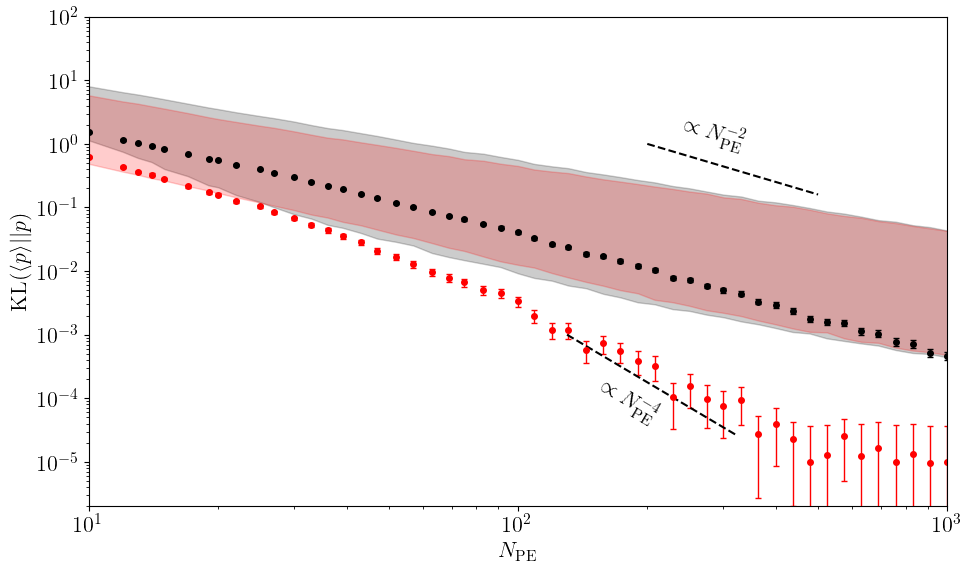

In [6]:
import jax
from jax.scipy.special import logsumexp as LSE
import jax.numpy as jnp
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '4'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.95'

nsample = 10000
npes = np.unique(np.logspace(1,3,51, dtype=int))
npes = tqdm(npes)
fig, axes = plt.subplots(nrows=1, sharex=False, figsize=(10,6))
# Nobs = 100
Nobs_list = [100]
ndim = 1
noise = 1
colors = ['k', 'r']
ax = axes
xlims = [1e1, 4e2]
ylims = [2e-6, 1e2]


# for aleph in [0,1]:
if True:
    
    Nobs = Nobs_list[0]
    
    # ax.set_title(f'Nobs = {Nobs}')
    acc_npe = []
    mean_kls = []
    kls = []
    unc_mean_kls = []
    success = 0
    for npe in npes:
        npes.set_description(f'Number succeed: {success}, NPE: {npe}')
        try:
            with open(f'corrected_data/noise{int(noise)}p{int((noise - int(noise))*10)}_Nobs{Nobs}_nsample{nsample}_posteriors/npe_{npe}.pkl', 'rb') as ff:
                dictionary = pkl.load(ff)
                
        except:
            continue
        acc_npe.append(npe)
        success += 1
        posteriors = jnp.array(dictionary['posteriors'][:,:2,...])
        # so we can plot both on top
        # print(posteriors.shape)
        sigma = dictionary['sigmas']
        analytical_posterior = dictionary['analytic_posterior']
        kl = dictionary['KL'][...,:2]
        
        mean_post = LSE(posteriors, axis=0) - jnp.log(posteriors.shape[0])
        # log_second_moment_post =jnp.array(
        #     [LSE(posteriors[...,None,index] + posteriors - mean_post[None,...,index,None] - mean_post[None,...] - jnp.log(posteriors.shape[0] - 1) - jnp.log(posteriors.shape[0]), axis=0)
        #     for index in tqdm(range(posteriors.shape[-1]))])
        f = lambda index: LSE(posteriors[...,None,index] + posteriors - mean_post[None,...,index,None] - mean_post[None,...] - jnp.log(posteriors.shape[0] - 1) - jnp.log(posteriors.shape[0]), axis=0)
        log_second_moment_post = jax.lax.map(f, jnp.arange(posteriors.shape[-1]))
        # log_second_moment_post = LSE(2*posteriors - 2*mean_post[None,None,...] - np.log(nsample/4 - 1) - np.log(nsample/4), axis=0)
        cov_post = (jnp.exp(log_second_moment_post) - 1 / (posteriors.shape[0] - 1))
        # print(var_post)
        # print(posteriors.shape[0])
        mean_kl = jnp.trapezoid(jnp.exp(analytical_posterior) * (analytical_posterior - mean_post), x=sigma, axis=-1)
        unc_mean_kl = jnp.trapezoid(jnp.exp(analytical_posterior)[None,None,:] * cov_post, x=sigma, axis=-1)
        unc_mean_kl = jnp.trapezoid(jnp.exp(analytical_posterior)[:,None] * unc_mean_kl, x=sigma, axis=0)
        mean_kls.append(mean_kl)
        unc_mean_kls.append(np.sqrt(np.abs(unc_mean_kl)+1e-10))
        kls.append(kl)
    mean_kls = np.array(mean_kls)
    kls = np.array(kls)
    unc_mean_kls = np.array(unc_mean_kls)
    print(kls.shape, mean_kls.shape)
    for ii, color in enumerate(colors):
        ax.fill_between(acc_npe, np.percentile(kls[:,:,ii], 5, axis=1), np.percentile(kls[:,:,ii], 95, axis=1), color=color, alpha=0.2)
        # ax.plot(acc_npe, mean_kls[:,ii], color=color)
        ax.errorbar(acc_npe, mean_kls[:,ii], yerr=2*unc_mean_kls[:,ii], color=color, linestyle='', marker='o', markersize=4, capsize=2, linewidth=1)
        
    xs = np.linspace(100,250,30)
    ax.plot(xs*1.3, 1e-3 * (xs/100)**(-4), 'k--')
    ax.plot(2*xs, (xs/100)**(-2), 'k--')

    ax.set_xlim([xlims[0], xlims[1]])
    ax.set_ylim([ylims[0], ylims[1]])
    ax.set_yscale('log')
    ax.set_xscale('log')
    a, b = ax.get_xlim()
    xsize, ysize = fig.get_size_inches()
    xscale = np.log(b/a) * xsize
    a, b = ax.get_ylim()
    yscale = np.log(b/a) * ysize
    
    CurvedText(x=xs[3:]*1.3, y=0.25*1e-3 * (xs[3:]/100)**(-4), text="$\propto N_{\\rm PE}^{-4}$", ha='center', va='bottom', axes=ax, latex=True) #""
    CurvedText(x=2*xs[3:], y=2* (xs[3:]/100)**(-2), text="$\propto N_{\\rm PE}^{-2}$", ha='center', va='bottom', axes=ax, latex=True) #"$\propto N_{\\rm PE}^{-2}$"
    
    # ax.fill_between(acc_npe, np.percentile(mc_arr, 5, axis=1), np.percentile(mc_arr, 95, axis=1), color=color, alpha=0.2)
    # ax.grid(visible=True)

plt.ylabel('KL$(\langle p\\rangle || p)$')
plt.xlabel('$N_{\\rm PE}$')

plt.tight_layout()
plt.savefig('../../../draft/plots/KL_npe_noise1.pdf')
plt.show()


Number succeed: 0, NPE: 10:   0%|          | 0/41 [00:00<?, ?it/s]

Number succeed: 0, NPE: 398: 100%|██████████| 41/41 [00:00<00:00, 614.39it/s]

(0,) (0,)


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

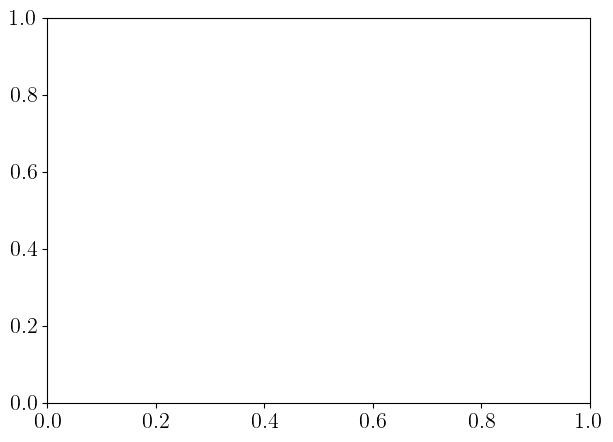

In [5]:
import jax
from jax.scipy.special import logsumexp as LSE
import jax.numpy as jnp
import numpy as np
import os
from tqdm import tqdm
os.environ['CUDA_VISIBLE_DEVICES'] = '4'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.95'

nsample = 10000
larger_nsample = 100000
npes = np.array(
    [10,  11,  12,  13,  14,  15,  17,  19,  20,  22,  25,  27,  30,  33,
     36,  39,  43,  47,  52,  57,  63,  69,  75,  83,  91, 100, 109,
     120, 131, 144, 158, 173, 190, 208, 229, 251, 275, 301, 331, 363,
     398])
larger_npe = npes[24:]
npes = tqdm(npes)
fig, axes = plt.subplots(nrows=1, sharex=False, figsize=(7,5))

ndim = 1
noise = 1
colors = ['k', 'r']
ax = axes
xlims = [1e1, 4e2]
ylims = [5e-6, 1e1]
    
Nobs = 100
acc_npe = []
mean_kls = []
kls = []
unc_mean_kls = []
success = 0
for npe in npes:
    npes.set_description(f'Number succeed: {success}, NPE: {npe}')
    if npe in larger_npe:
        try:
            with open(f'../../../data/one_dimensional_data/noise{int(noise)}p{int((noise - int(noise))*10)}_Nobs{Nobs}_nsample{larger_nsample}_posteriors/npe_{npe}.pkl', 'rb') as ff:
                dictionary = pkl.load(ff)
        except:
            continue
    else:
        try:
            with open(f'../../../data/one_dimensional_data/noise{int(noise)}p{int((noise - int(noise))*10)}_Nobs{Nobs}_nsample{nsample}_posteriors/npe_{npe}.pkl', 'rb') as ff:
                dictionary = pkl.load(ff)
        except:
            continue
    acc_npe.append(npe)
    success += 1
    posteriors = jnp.array(dictionary['posteriors'][:,:2,...])
    # so we can plot both on top
    # print(posteriors.shape)
    sigma = dictionary['sigmas']
    analytical_posterior = dictionary['analytic_posterior']
    kl = dictionary['KL'][...,:2]
    
    mean_post = LSE(posteriors, axis=0) - jnp.log(posteriors.shape[0])
    # log_second_moment_post =jnp.array(
    #     [LSE(posteriors[...,None,index] + posteriors - mean_post[None,...,index,None] - mean_post[None,...] - jnp.log(posteriors.shape[0] - 1) - jnp.log(posteriors.shape[0]), axis=0)
    #     for index in tqdm(range(posteriors.shape[-1]))])
    f = lambda index: LSE(posteriors[...,None,index] + posteriors - mean_post[None,...,index,None] - mean_post[None,...] - jnp.log(posteriors.shape[0] - 1) - jnp.log(posteriors.shape[0]), axis=0)
    log_second_moment_post = jax.lax.map(f, jnp.arange(posteriors.shape[-1]))
    # log_second_moment_post = LSE(2*posteriors - 2*mean_post[None,None,...] - np.log(nsample/4 - 1) - np.log(nsample/4), axis=0)
    cov_post = (jnp.exp(log_second_moment_post) - 1 / (posteriors.shape[0] - 1))
    # print(var_post)
    # print(posteriors.shape[0])
    mean_kl = jnp.trapezoid(jnp.exp(analytical_posterior) * (analytical_posterior - mean_post), x=sigma, axis=-1) / np.log(2)
    unc_mean_kl = jnp.trapezoid(jnp.exp(analytical_posterior)[None,None,:] * cov_post, x=sigma, axis=-1)
    unc_mean_kl = jnp.trapezoid(jnp.exp(analytical_posterior)[:,None] * unc_mean_kl, x=sigma, axis=0) / np.log(2)**2
    mean_kls.append(mean_kl)
    unc_mean_kls.append(np.sqrt(np.abs(unc_mean_kl)+1e-10))
    kls.append(kl[:nsample,:])
mean_kls = np.array(mean_kls)
kls = np.array(kls)
unc_mean_kls = np.array(unc_mean_kls)
print(kls.shape, mean_kls.shape)
subscript = ['', 'C']

# for ii, color in enumerate(colors):
#     ax.fill_between(acc_npe, np.percentile(kls[:,:,ii], 5, axis=1), np.percentile(kls[:,:,ii], 95, axis=1), color=color, alpha=0.2, label=f'KL$(\hat{{p}}_{{{subscript[ii]}}}\,|\,p)$')
for ii, color in enumerate(colors):
    ax.errorbar(acc_npe, mean_kls[:,ii], yerr=2*unc_mean_kls[:,ii], color=color, linestyle='', marker='o', markersize=4, capsize=2, linewidth=1, label=f'KL$(p | \langle\hat{{p}}_{{{subscript[ii]}}}\\rangle)$')
    # ax.scatter(np.ones(3), np.zeros(3), marker='o', color=color, label=f'KL$(p||\langle\hat{{p}}_{{{subscript[ii]}}}\\rangle)$')
xs = np.linspace(200,500,30)
ax.plot(xs, 6e-4 * (xs/xs[0])**(-4), 'k--')
ax.plot(0.75*xs, 9e-2*(1.5*xs/xs[0])**(-2), 'k--')

ax.set_xlim([xlims[0], xlims[1]])
ax.set_yscale('log')
ax.set_xscale('log')
a, b = ax.get_xlim()
xsize, ysize = fig.get_size_inches()
xscale = np.log(b/a) * xsize
a, b = ax.get_ylim()
yscale = np.log(b/a) * ysize

CurvedText(x=xs, y=3*6e-4 * (xs[3:]/xs[0])**(-4), text="$\propto N_{\\rm PE}^{-4}$", ha='center', va='bottom', axes=ax, latex=True) #""
CurvedText(x=0.75*xs[3:], y=2*9e-2*(1.5*xs[3:]/xs[0])**(-2), text="$\propto N_{\\rm PE}^{-2}$", ha='center', va='bottom', axes=ax, latex=True) #"$\propto N_{\\rm PE}^{-2}$"

ax.set_yticks(np.logspace(-5,1,7))
ax.set_yticks(np.outer(np.linspace(0.1,0.9,9),np.logspace(-5,1,7)).flatten(), minor=True)
ax.set_ylim([ylims[0], ylims[1]])

# ax.fill_between(acc_npe, np.percentile(mc_arr, 5, axis=1), np.percentile(mc_arr, 95, axis=1), color=color, alpha=0.2)
    # ax.grid(visible=True)

plt.legend(loc='lower left', frameon=True, borderpad=0.3, labelspacing=0.3, columnspacing=0.5, handlelength=1, borderaxespad=0.3)
# plt.ylabel('KL$(\langle \hat{p}\\rangle || p)$ [bits]')
plt.ylabel('KL divergence [bits]')
plt.xlabel('$N_{\\rm PE}$')

plt.tight_layout()
plt.savefig('../../../draft/plots/larger_KL_npe_noise1.pdf')
plt.show()


Number succeed: 0, NPE: 10:   0%|          | 0/51 [00:00<?, ?it/s]

Number succeed: 50, NPE: 1000: 100%|██████████| 51/51 [00:21<00:00,  2.33it/s]


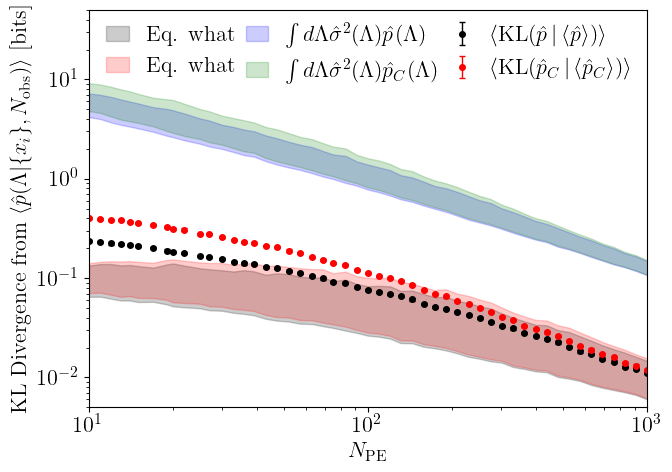

Now with variance thresholds

In [ ]:
import jax
from jax.scipy.special import logsumexp as LSE
import jax.numpy as jnp
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '4'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.95'

nsample = 10000
larger_nsample = 100000
npes = np.array(
    [10,  11,  12,  13,  14,  15,  17,  19,  20,  22,  25,  27,  30,  33,
     36,  39,  43,  47,  52,  57,  63,  69,  75,  83,  91, 100, 109,
     120, 131, 144, 158, 173, 190, 208, 229, 251, 275, 301, 331, 363,
     398])
larger_npe = npes[24:]
npes = tqdm(npes)
fig, axes = plt.subplots(nrows=1, sharex=False, figsize=(6,5))
# Nobs = 100
Nobs_list = [100]
ndim = 1
noise = 1
colors = ['k', 'r']
ax = axes
xlims = [1e1, 4e2]
ylims = [5e-6, 1e2]

variance_threshold = 1
# for aleph in [0,1]:
if True:
    
    Nobs = Nobs_list[0]
    
    # ax.set_title(f'Nobs = {Nobs}')
    acc_npe = []
    mean_kls = []
    kls = []
    unc_mean_kls = []
    success = 0
    for npe in npes:
        npes.set_description(f'Number succeed: {success}, NPE: {npe}')
        if npe in larger_npe:
            try:
                with open(f'corrected_data/noise{int(noise)}p{int((noise - int(noise))*10)}_Nobs{Nobs}_nsample{larger_nsample}_posteriors/npe_{npe}.pkl', 'rb') as ff:
                    dictionary = pkl.load(ff)
            except:
                continue
        else:
            try:
                with open(f'corrected_data/noise{int(noise)}p{int((noise - int(noise))*10)}_Nobs{Nobs}_nsample{nsample}_posteriors/npe_{npe}.pkl', 'rb') as ff:
                    dictionary = pkl.load(ff)
            except:
                continue
        acc_npe.append(npe)
        success += 1
        posteriors = jnp.array(dictionary['posteriors'][:,:2,...])
        variance = dictionary['mean_variance']
        
        sigma = dictionary['sigmas']
        analytical_posterior = dictionary['analytic_posterior']
        kl = dictionary['KL'][...,:2]
        # reject 

        
        mean_post = LSE(posteriors, axis=0) - jnp.log(posteriors.shape[0])
        
        f = lambda index: LSE(posteriors[...,None,index] + posteriors - mean_post[None,...,index,None] - mean_post[None,...] - jnp.log(posteriors.shape[0] - 1) - jnp.log(posteriors.shape[0]), axis=0)
        log_second_moment_post = jax.lax.map(f, jnp.arange(posteriors.shape[-1]))
        # log_second_moment_post = LSE(2*posteriors - 2*mean_post[None,None,...] - np.log(nsample/4 - 1) - np.log(nsample/4), axis=0)
        cov_post = (jnp.exp(log_second_moment_post) - 1 / (posteriors.shape[0] - 1))
        # print(var_post)
        # print(posteriors.shape[0])
        mean_kl = jnp.trapezoid(jnp.exp(analytical_posterior) * (analytical_posterior - mean_post), x=sigma, axis=-1) / np.log(2)
        unc_mean_kl = jnp.trapezoid(jnp.exp(analytical_posterior)[None,None,:] * cov_post, x=sigma, axis=-1)
        unc_mean_kl = jnp.trapezoid(jnp.exp(analytical_posterior)[:,None] * unc_mean_kl, x=sigma, axis=0) / np.log(2)**2
        mean_kls.append(mean_kl)
        unc_mean_kls.append(np.sqrt(np.abs(unc_mean_kl)+1e-10))
        kls.append(kl[:nsample,:])
    mean_kls = np.array(mean_kls)
    kls = np.array(kls)
    unc_mean_kls = np.array(unc_mean_kls)
    print(kls.shape, mean_kls.shape)
    subscript = ['', 'C']
    
    for ii, color in enumerate(colors):
        ax.fill_between(acc_npe, np.percentile(kls[:,:,ii], 5, axis=1), np.percentile(kls[:,:,ii], 95, axis=1), color=color, alpha=0.2, label=f'KL$(p|| \;\hat{{p}}_{{{subscript[ii]}}})$')
    for ii, color in enumerate(colors):
        ax.errorbar(acc_npe, mean_kls[:,ii], yerr=2*unc_mean_kls[:,ii], color=color, linestyle='', marker='o', markersize=4, capsize=2, linewidth=1, label=f'KL$(p||\langle\hat{{p}}_{{{subscript[ii]}}}\\rangle)$')
        # ax.scatter(np.ones(3), np.zeros(3), marker='o', color=color, label=f'KL$(p||\langle\hat{{p}}_{{{subscript[ii]}}}\\rangle)$')
    xs = np.linspace(200,500,30)
    ax.plot(xs, 6e-4 * (xs/xs[0])**(-4), 'k--')
    ax.plot(0.75*xs, 9e-2*(1.5*xs/xs[0])**(-2), 'k--')

    ax.set_xlim([xlims[0], xlims[1]])
    ax.set_ylim([ylims[0], ylims[1]])
    ax.set_yscale('log')
    ax.set_xscale('log')
    a, b = ax.get_xlim()
    xsize, ysize = fig.get_size_inches()
    xscale = np.log(b/a) * xsize
    a, b = ax.get_ylim()
    yscale = np.log(b/a) * ysize
    
    CurvedText(x=xs, y=3*6e-4 * (xs[3:]/xs[0])**(-4), text="$\propto N_{\\rm PE}^{-4}$", ha='center', va='bottom', axes=ax, latex=True) #""
    CurvedText(x=0.75*xs[3:], y=2*9e-2*(1.5*xs[3:]/xs[0])**(-2), text="$\propto N_{\\rm PE}^{-2}$", ha='center', va='bottom', axes=ax, latex=True) #"$\propto N_{\\rm PE}^{-2}$"
    
    # ax.fill_between(acc_npe, np.percentile(mc_arr, 5, axis=1), np.percentile(mc_arr, 95, axis=1), color=color, alpha=0.2)
    # ax.grid(visible=True)

plt.legend(frameon=False, loc='upper right', borderpad=0.1, labelspacing=0.3)

# plt.ylabel('KL$(\langle \hat{p}\\rangle || p)$ [bits]')
plt.ylabel('KL Divergence from $p(\\Lambda|\{x_i\}, N_{\\rm obs})$ [bits]')
plt.xlabel('$N_{\\rm PE}$')

plt.tight_layout()
plt.savefig('../../../draft/plots/variance_thresh_larger_KL_npe_noise1.pdf')
plt.show()


Number succeed: 2, NPE: 1000: 100%|██████████| 3/3 [00:14<00:00,  4.76s/it]


(3, 100, 2) (3, 2)


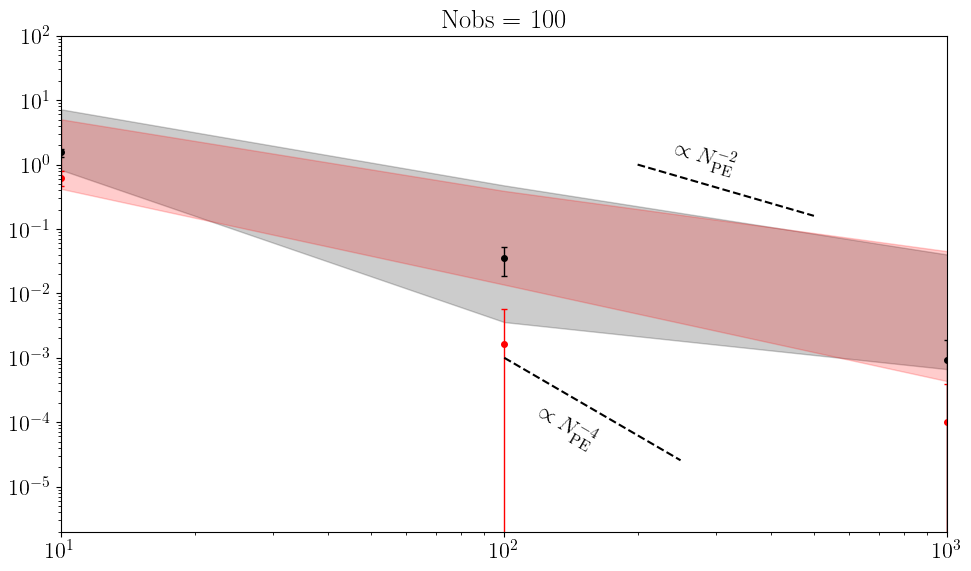

In [2]:
import jax
from jax.scipy.special import logsumexp as LSE
import jax.numpy as jnp
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '4'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.95'

nsample = 100
npes = np.unique(np.logspace(1,3,51, dtype=int))
npes = np.array([10,100,1000])
npes = tqdm(npes)

fig, axes = plt.subplots(nrows=1, sharex=False, figsize=(10,6))
# Nobs = 100
Nobs_list = [100]
ndim = 1
noise = 1
colors = ['k', 'r']
ax = axes
xlims = [1e1, 1e3]
ylims = [2e-6, 1e2]


# for aleph in [0,1]:
if True:
    
    Nobs = Nobs_list[0]
    ax.set_title(f'Nobs = {Nobs}')
    acc_npe = []
    mean_kls = []
    kls = []
    unc_mean_kls = []
    success = 0
    for npe in npes:
        npes.set_description(f'Number succeed: {success}, NPE: {npe}')
        try:
            with open(f'corrected_data/noise{int(noise)}p{int((noise - int(noise))*10)}_Nobs{Nobs}_nsample{nsample}_posteriors/npe_{npe}.pkl', 'rb') as ff:
                dictionary = pkl.load(ff)
                
        except:
            continue
        acc_npe.append(npe)
        success += 1
        posteriors = jnp.array(dictionary['posteriors'][:,:2,...])
        # so we can plot both on top
        # print(posteriors.shape)
        sigma = dictionary['sigmas']
        analytical_posterior = dictionary['analytic_posterior']
        kl = dictionary['KL'][...,:2]
        
        mean_post = LSE(posteriors, axis=0) - jnp.log(posteriors.shape[0])
        # log_second_moment_post =jnp.array(
        #     [LSE(posteriors[...,None,index] + posteriors - mean_post[None,...,index,None] - mean_post[None,...] - jnp.log(posteriors.shape[0] - 1) - jnp.log(posteriors.shape[0]), axis=0)
        #     for index in tqdm(range(posteriors.shape[-1]))])
        f = lambda index: LSE(posteriors[...,None,index] + posteriors - mean_post[None,...,index,None] - mean_post[None,...] - jnp.log(posteriors.shape[0] - 1) - jnp.log(posteriors.shape[0]), axis=0)
        log_second_moment_post = jax.lax.map(f, jnp.arange(posteriors.shape[-1]))
        # log_second_moment_post = LSE(2*posteriors - 2*mean_post[None,None,...] - np.log(nsample/4 - 1) - np.log(nsample/4), axis=0)
        cov_post = (jnp.exp(log_second_moment_post) - 1 / (posteriors.shape[0] - 1))
        # print(var_post)
        # print(posteriors.shape[0])
        mean_kl = jnp.trapezoid(jnp.exp(analytical_posterior) * (analytical_posterior - mean_post), x=sigma, axis=-1)
        unc_mean_kl = jnp.trapezoid(jnp.exp(analytical_posterior)[None,None,:] * cov_post, x=sigma, axis=-1)
        unc_mean_kl = jnp.trapezoid(jnp.exp(analytical_posterior)[:,None] * unc_mean_kl, x=sigma, axis=0)
        mean_kls.append(mean_kl)
        unc_mean_kls.append(np.sqrt(np.abs(unc_mean_kl)+1e-10))
        kls.append(kl)
    mean_kls = np.array(mean_kls)
    kls = np.array(kls)
    unc_mean_kls = np.array(unc_mean_kls)
    print(kls.shape, mean_kls.shape)
    for ii, color in enumerate(colors):
        ax.fill_between(acc_npe, np.percentile(kls[:,:,ii], 5, axis=1), np.percentile(kls[:,:,ii], 95, axis=1), color=color, alpha=0.2)
        # ax.plot(acc_npe, mean_kls[:,ii], color=color)
        ax.errorbar(acc_npe, mean_kls[:,ii], yerr=2*unc_mean_kls[:,ii], color=color, linestyle='', marker='o', markersize=4, capsize=2, linewidth=1)
        
    xs = np.linspace(100,250,30)
    ax.plot(xs, 1e-3 * (xs/100)**(-4), 'k--')
    ax.plot(2*xs, (xs/100)**(-2), 'k--')

    ax.set_xlim([xlims[0], xlims[1]])
    ax.set_ylim([ylims[0], ylims[1]])
    ax.set_yscale('log')
    ax.set_xscale('log')
    a, b = ax.get_xlim()
    xsize, ysize = fig.get_size_inches()
    xscale = np.log(b/a) * xsize
    a, b = ax.get_ylim()
    yscale = np.log(b/a) * ysize
    
    CurvedText(x=xs[3:], y=0.25*1e-3 * (xs[3:]/100)**(-4), text="$\propto N_{\\rm PE}^{-4}$", ha='center', va='bottom', axes=ax, latex=True) #""
    CurvedText(x=2*xs[3:], y=2* (xs[3:]/100)**(-2), text="$\propto N_{\\rm PE}^{-2}$", ha='center', va='bottom', axes=ax, latex=True) #"$\propto N_{\\rm PE}^{-2}$"
    
    # ax.fill_between(acc_npe, np.percentile(mc_arr, 5, axis=1), np.percentile(mc_arr, 95, axis=1), color=color, alpha=0.2)
    # ax.grid(visible=True)
    
plt.tight_layout()
plt.show()


1.3906534 0.40379304


2.3904614 0.40094528
3.385996 0.40604684


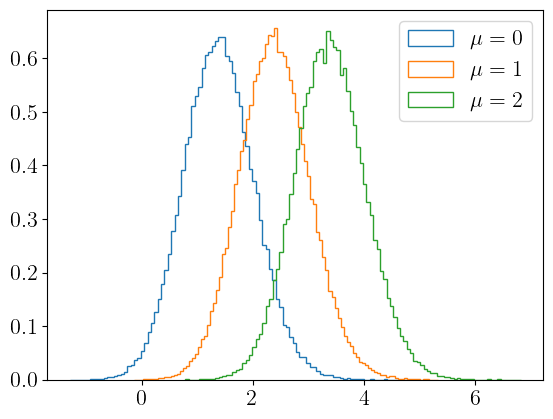

In [14]:
# draw some normal values
N = 3
Nsample = 100_000

means = [0,1,2]
sigmas = [1,1,1]

key = jax.random.PRNGKey(0)

for mean, sigma in zip(means, sigmas):
    key, _ = jax.random.split(key)
    x = sigma*jax.random.normal(key, shape=(N, Nsample))+mean
    lse = LSE(x, axis=0)
    print(np.mean(lse), np.var(lse))
    plt.hist(lse, bins=100, density=True, histtype='step', label=f'$\mu={mean}$')
plt.legend()
# plt.yscale('log')


1.3906534 0.40379304
2.020707 1.8837652
2.7525842 4.59018


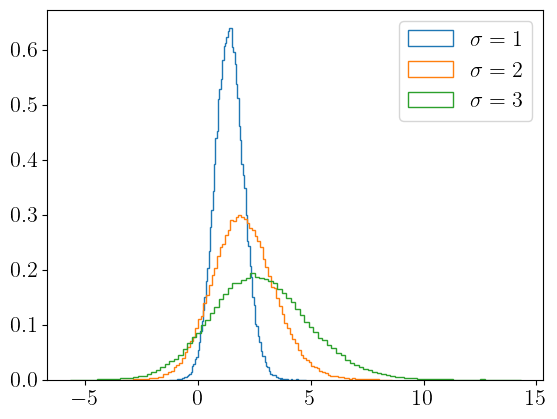

In [18]:
N = 3
Nsample = 100_000

means = [0,0,0]
sigmas = [1,2,3]

key = jax.random.PRNGKey(0)

for mean, sigma in zip(means, sigmas):
    key, _ = jax.random.split(key)
    x = sigma*jax.random.normal(key, shape=(N, Nsample))+mean
    lse = LSE(x, axis=0)
    print(np.mean(lse), np.var(lse))
    plt.hist(lse, bins=100, density=True, histtype='step', label=f'$\sigma={sigma}$')
plt.legend()
# plt.yscale('log')

1.3906534 0.40379304
2.7288094 0.14453465
3.8744853 0.052703407


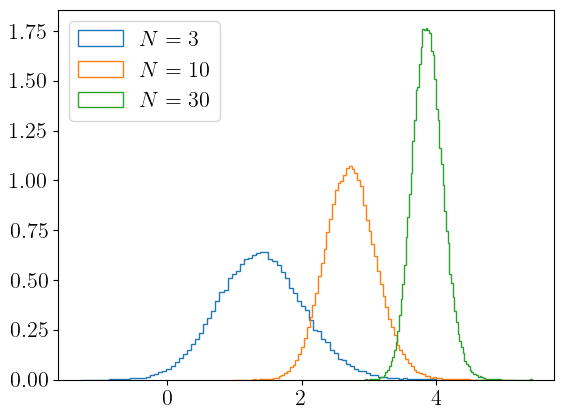

In [15]:
N = 3
Nsample = 100_000

means = [0,0,0]
sigmas = [1,0,3]
mean = 0
sigma = 1
Ns = [3,10,30]

key = jax.random.PRNGKey(0)

for N in Ns:
    key, _ = jax.random.split(key)
    x = sigma*jax.random.normal(key, shape=(N, Nsample))+mean
    lse = LSE(x, axis=0)
    print(np.mean(lse), np.var(lse))
    plt.hist(lse, bins=100, density=True, histtype='step', label=f'$N={N}$')
plt.legend()
# plt.yscale('log')

empirical 84.71572 5576.4775
predicted 4900.549306144334 9998.901387711332
empirical 153.87114 3448.99
predicted 4901.151292546497 9997.697414907007
empirical 204.12291 2451.136
predicted 4901.700598690831 9996.598802618339


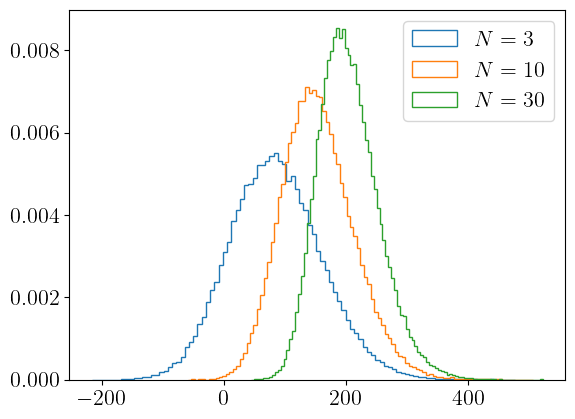

In [17]:
N = 3
Nsample = 100_000

means = [0,0,0]
sigmas = [1,0,3]
mean = 0
sigma = 100
Ns = [3,10,30]

key = jax.random.PRNGKey(0)

for N in Ns:
    key, _ = jax.random.split(key)
    x = sigma*jax.random.normal(key, shape=(N, Nsample))+mean
    lse = LSE(x, axis=0)
    print('empirical', np.mean(lse), np.var(lse))
    print('predicted', mean+sigma**2 / 2 + 0.5*np.log(N) - sigma, sigma**2 - np.log(N))
    
    plt.hist(lse, bins=100, density=True, histtype='step', label=f'$N={N}$')
plt.legend()

## Simple Gaussian example, with GP scatter

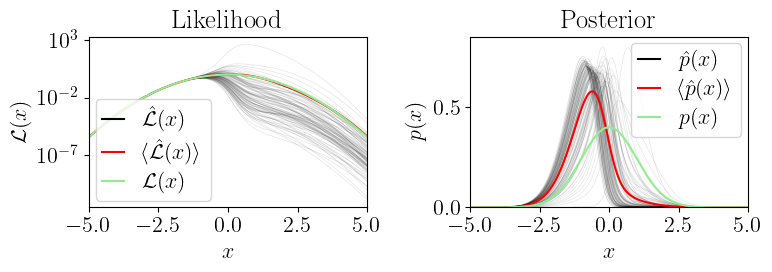

In [2]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '2'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.5'

import jax
jax.config.update("jax_enable_x64", True)

from jax.scipy.special import logsumexp as LSE
import jax.numpy as jnp
import jax
import matplotlib
import matplotlib.pyplot as plt

plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=16)


from tinygp import GaussianProcess
from tinygp import kernels

Nsample = 1000

kernel = kernels.ExpSquared(scale=5)
# Let's make up some input coordinates (sorted for plotting purposes)
x = jnp.linspace(-5,5,200)
dx = x[1] - x[0]

gp = GaussianProcess(kernel, x)
y = gp.sample(jax.random.PRNGKey(4), shape=(Nsample,))
modifier = 3*jax.nn.sigmoid(3*x[:,None])
scatter = modifier*y.T

log_likelihood = -x**2 / 2
log_ls = log_likelihood[:,None]+scatter - 0.5*(modifier)**2 # ensure it is an unbiased L estimator
mean_l = LSE(log_ls, axis=-1) - jnp.log(log_ls.shape[-1])


fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8,3))

exp = True
Nplot = 100
if exp:
    ax[0].plot(x, jnp.exp(log_ls)[:,:Nplot], color="k", lw=0.5, alpha=0.1)
    ax[0].plot(x, jnp.exp(mean_l), color='r')
    ax[0].plot(x, jnp.exp(log_likelihood), color='lightgreen')
    ax[0].set_yscale('log')
else:
    ax[0].plot(x, log_ls, color="k", lw=0.5, alpha=0.05)
    ax[0].plot(x, mean_l, color='r')
    ax[0].plot(x, log_likelihood, color='lightgreen')

ax[0].set_xlabel("$x$")
ax[0].set_ylabel("$\mathcal{L}(x)$")
ax[0].set_title("Likelihood")
ax[0].legend([matplotlib.lines.Line2D([], [], color='k'), matplotlib.lines.Line2D([], [], color='r'), matplotlib.lines.Line2D([], [], color='lightgreen')],
             ['$\hat{\mathcal{L}}(x)$', '$\langle\hat{\mathcal{L}}(x)\\rangle$', '$\mathcal{L}(x)$'], loc='lower left', frameon=True, borderpad=0.3, labelspacing=0.3, columnspacing=0.5, handlelength=1, borderaxespad=0.3)

log_evidences = LSE(log_ls, axis=0) + jnp.log(dx)
posteriors = jnp.exp(log_ls - log_evidences[None,...])

mean_post = jnp.mean(posteriors, axis=-1)
true_post = jnp.exp(log_likelihood - LSE(log_likelihood, axis=0) - jnp.log(dx))

ax[1].plot(x, posteriors[:,:Nplot], color="k", lw=0.5, alpha=0.1, label='Likelihood Samples')
ax[1].set_xlabel("$x$")
ax[1].set_ylabel("$p(x)$")
ax[1].set_title("Posterior")
ax[1].plot(x, mean_post, color='r', label='Mean of posteriors')
ax[1].plot(x, true_post, color='lightgreen')

ax[0].set_xlim([-5,5])
ax[1].set_xlim([-5,5])
ax[1].set_ylim([0,0.85])
ax[1].legend([matplotlib.lines.Line2D([], [], color='k'), matplotlib.lines.Line2D([], [], color='r'), matplotlib.lines.Line2D([], [], color='lightgreen')],
             ['$\hat{p}(x)$', '$\langle\hat{p}(x)\\rangle$', '$p(x)$'], loc='upper right', frameon=True, borderpad=0.3, labelspacing=0.3, columnspacing=0.5, handlelength=1, borderaxespad=0.3)


plt.tight_layout()
plt.savefig('../../../draft/plots/continuous_likelihood_bias_schematic.pdf')
plt.show()

### no, go even simpler, just a categorical inference, is it A, B, or C?

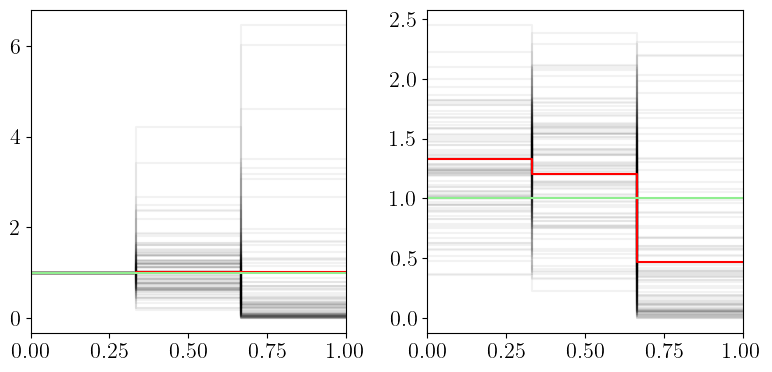

In [52]:
Nrandom = 10000
Nplot = 100
x = jnp.array([0,1/3,2/3,1.1])
log_likelihoods = jnp.array([0, 0, 0, 0])
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.95'

import jax
jax.config.update("jax_enable_x64", True)

from jax.scipy.special import logsumexp as LSE
import jax.numpy as jnp
import jax
from matplotlib import pyplot as plt
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=16)


uncertainty_envelopes = jnp.array([0.0,0.5,2,0])[:,None]
uncertainties = jax.random.normal(jax.random.PRNGKey(1), shape=(4,Nrandom)) * uncertainty_envelopes - 0.5*uncertainty_envelopes**2 # mean of lognormal is e^mu*e^0.5*var

lls = log_likelihoods[:,None] + uncertainties
mean_lls = LSE(lls, axis=-1) - jnp.log(Nrandom)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8,4))

ax[0].step(x, jnp.exp(lls)[:,:Nplot], where='post', alpha=0.05, color='k')
ax[0].step(x, jnp.exp(mean_lls), where='post', color='r')
ax[0].step(x, jnp.exp(log_likelihoods), where='post', color='lightgreen')
ax[0].set_xlim([0,1])

evidences = LSE(lls[:-1,:], axis=0) + jnp.log(1/3) # ignore last dummy variable
posteriors = jnp.exp(lls - evidences[None,:])
mean_posterior = jnp.mean(posteriors, axis=-1)

ax[1].step(x, posteriors[:,:Nplot], where='post', alpha=0.05, color='k')
ax[1].step(x, mean_posterior, where='post', color='r')
ax[1].step(x, jnp.exp(log_likelihoods), where='post', color='lightgreen')
ax[1].set_xlim([0,1])

# plt.yscale('log')
plt.tight_layout()
plt.savefig('../../../draft/plots/discrete_likelihood_bias_schematic.pdf')
plt.show()

### Accurate vs Precise

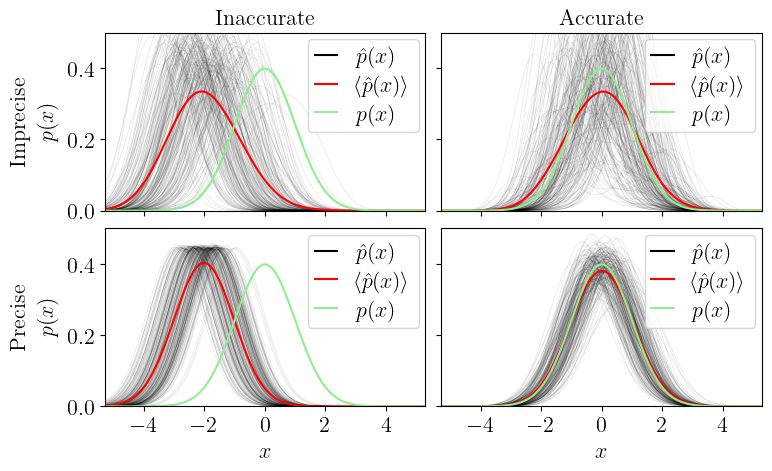

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '2'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.5'

import jax
jax.config.update("jax_enable_x64", True)

from jax.scipy.special import logsumexp as LSE
import jax.numpy as jnp
import jax
import matplotlib
import matplotlib.pyplot as plt

plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=16)


from tinygp import GaussianProcess
from tinygp import kernels

Nsample = 200

# Let's make up some input coordinates (sorted for plotting purposes)
x = jnp.linspace(-6,6,250)
dx = x[1] - x[0]

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(8,5), sharex=True, sharey=True)

for ii, precise in enumerate([False, True]):
    for jj, accurate in enumerate([False, True]):

        if precise and accurate:
            kernel = kernels.ExpSquared(scale=3.)
            modifier = 1.
        elif precise and (not accurate):
            kernel = kernels.ExpSquared(scale=50)
            modifier = 1.*((x[:,None] + 10.) / 2)
        elif accurate and (not precise):
            kernel = kernels.ExpSquared(scale=1.5)
            modifier = 1.5
        else:
            kernel = kernels.ExpSquared(scale=5)
            modifier = (x[:,None]+10.)/2

        gp = GaussianProcess(kernel, x)
        y = gp.sample(jax.random.PRNGKey(4), shape=(Nsample,))
        
        scatter = modifier*y.T

        log_likelihood = -x**2 / 2
        log_ls = log_likelihood[:,None]+scatter - 0.5*(modifier)**2 # ensure it is an unbiased L estimator
        mean_l = LSE(log_ls, axis=-1) - jnp.log(log_ls.shape[-1])

        log_evidences = LSE(log_ls, axis=0) + jnp.log(dx)
        posteriors = jnp.exp(log_ls - log_evidences[None,...])

        mean_post = jnp.mean(posteriors, axis=-1)
        true_post = jnp.exp(log_likelihood - LSE(log_likelihood, axis=0) - jnp.log(dx))
        
        # ax[ii,jj].set_title(f'Precise = {precise}, Accurate = {accurate}')
        # if not precise:
        #     text1 = 'Not precise, '
        # else:
        #     text1 = 'Precise, '
        # if not accurate:
        #     text2 = 'not accurate'
        # else:
        #     text2 = 'accurate'
        # ax[ii,jj].text(-1, 0.45, text1)
        # ax[ii,jj].text(-1, 0.40, text2)
        
        ax[ii,jj].plot(x, posteriors, color="k", lw=0.5, alpha=0.1)
        ax[ii,jj].plot(x, mean_post, color='r')
        ax[ii,jj].plot(x, true_post, color='lightgreen')
        ax[ii,jj].set_xlim(-5.3,5.3)
        ax[ii,jj].set_ylim(0,0.5)

        ax[ii,jj].set_xticks(jnp.linspace(-4,4,5), minor=False)

        ax[ii,jj].legend([matplotlib.lines.Line2D([], [], color='k'), matplotlib.lines.Line2D([], [], color='r'), matplotlib.lines.Line2D([], [], color='lightgreen')],
             ['$\hat{p}(x)$', '$\langle\hat{p}(x)\\rangle$', '$p(x)$'], frameon=True, loc='upper right',  borderpad=0.3, labelspacing=0.3, columnspacing=0.5, handlelength=1, borderaxespad=0.3)# frameon=False, loc='upper right', borderpad=0.1, labelspacing=0.3, handlelength=1, borderaxespad=0.1)


ax[1,0].set_xlabel("$x$")
ax[1,1].set_xlabel("$x$")

ax[0,1].set_ylabel("$p(x)$", labelpad=272)
ax[1,1].set_ylabel("$p(x)$", labelpad=272)

ax[0,0].set_title('Inaccurate', fontsize=16)
ax[0,1].set_title('Accurate', fontsize=16)

ax[0,0].set_ylabel('Imprecise', fontsize=16, labelpad=27)
ax[1,0].set_ylabel('Precise', fontsize=16, labelpad=27)

plt.tight_layout()
plt.subplots_adjust(wspace=0.05, hspace=0.1)
plt.savefig('../../../draft/plots/precision_vs_accuracy.pdf')
plt.show()